---
author: "Eldar Mukhtarov"
date: today
format:
  html:
    theme: darkly
    toc: true
    code-fold: true
    self-contained: true
  pdf:
    number-sections: true
    colorlinks: true
    papersize: letter
    geometry:
      - top=30mm
      - left=20mm
---

# Comprehensive Data Analysis: HRP Database

This notebook performs a comprehensive data analysis on the HRP database, covering:

1. Setup and Connection
2. Senior Demographics
3. Measurement Volume and Types
4. Medical History Linkage
5. SOS Alert Analysis
6. Duplicate Analysis
7. Random Senior Samples
8. Alerts by hour
9. Vital Sign Profiles
10. Chronic Linkage

# 1. Setup and Connection

Connect to the HRP database and load the first 5 rows from each table to verify the schema.

In [114]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import gc
import duckdb

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

## 1.1 Connect and display DB tables

In [182]:
db_path = '../db/hrp_data.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [116]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]
print(f"Tables in database: {tables}\n")

Tables in database: ['seniors', 'measurements', 'sqlite_sequence', 'medical_info', 'diseases', 'medicines', 'senior_diseases', 'senior_medicines', 'alerts', 'ingestion_state']



## 1.2 Previewing major tables

In [117]:
table_list = ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']
print(f"Previewing tables: {table_list}")

Previewing tables: ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']


## 1.3 Overview of database tables

In [118]:
for table in table_list:
    try:
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        total_rows = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table}", conn)['count'][0]
        print(80 * "=")
        print(f"Table: {table} (Total rows: {total_rows:,})")
        print(80 * "=")
        print(f"Columns: {list(df.columns)}")
        print(f"Data types:\n{df.dtypes}\n")
        print(df.to_string(index=False))
    except Exception as e:
        print(f"Error reading table {table}: {e}")

Table: seniors (Total rows: 14,929)
Columns: ['id', 'gender', 'birthdate', 'age']
Data types:
id            int64
gender       object
birthdate    object
age           int64
dtype: object

  id gender  birthdate  age
2875 Female 1955-02-26   70
3175 Female 1956-09-02   69
3176 Female 1934-08-11   91
3178   Male 1932-12-13   93
3179 Female 1941-11-04   84
Table: measurements (Total rows: 255,019,140)
Columns: ['id', 'senior_id', 'value', 'sbp', 'dbp', 'date', 'type']
Data types:
id             int64
senior_id      int64
value        float64
sbp           object
dbp           object
date          object
type          object
dtype: object

 id  senior_id  value  sbp  dbp                date        type
  1      48129   36.3 None None 2025-11-03 23:16:12 Temperature
  2      48427   36.6 None None 2025-11-03 23:16:12 Temperature
  3      45310   36.3 None None 2025-11-03 23:16:12 Temperature
  4      29421   36.6 None None 2025-11-03 23:16:12 Temperature
  5      45316   36.9 None None 202

# 2. Senior Demographics

Analyze senior population statistics, NULL values, and age outliers.

## 2.1 Load seniors table into DataFrame

In [119]:
seniors_df = pd.read_sql_query("SELECT * FROM seniors", conn)

## 2.2 Senior data overview

In [120]:
total_seniors = len(seniors_df)
unique_senior_ids = seniors_df['id'].nunique()
print(f"Total seniors: {total_seniors}")
print(f"Unique senior ids: {unique_senior_ids}")

Total seniors: 14929
Unique senior ids: 14929


In [121]:
valid_genders = {'Male', 'Female'}
invalid_gender_rows = seniors_df[~seniors_df['gender'].isin(valid_genders)]
print(f"gender: {len(invalid_gender_rows)} UNKNOWN ({len(invalid_gender_rows)/total_seniors*100:.2f}%)")

null_counts = seniors_df[['birthdate', 'age']].isna().sum()
for col, count in null_counts.items():
    print(f"{col}: {count} NULLs ({count/total_seniors*100:.2f}%)")

gender: 208 UNKNOWN (1.39%)
birthdate: 392 NULLs (2.63%)
age: 375 NULLs (2.51%)


In [122]:
invalid_gender_rows[['id', 'gender', 'age', 'birthdate']].head()

,id,gender,age,birthdate
81,3896,None,NaN,None
1772,21379,Unknown,69.0,1956-11-26
1773,21380,Unknown,78.0,1947-02-19
1836,21602,Unknown,77.0,1948-11-14
1868,21853,Unknown,69.0,1956-10-19


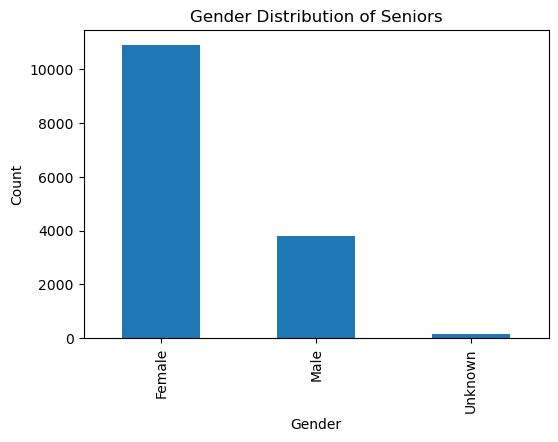

In [123]:
gender_counts = seniors_df['gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution of Seniors')
plt.show()

In [124]:
print(f"Min age: {seniors_df['age'].min()}")
print(f"Max age: {seniors_df['age'].max()}")
print(f"Mean age: {seniors_df['age'].mean():.2f}")
print(f"Median age: {seniors_df['age'].median():.2f}")

Min age: -75.0
Max age: 126.0
Mean age: 75.76
Median age: 77.00


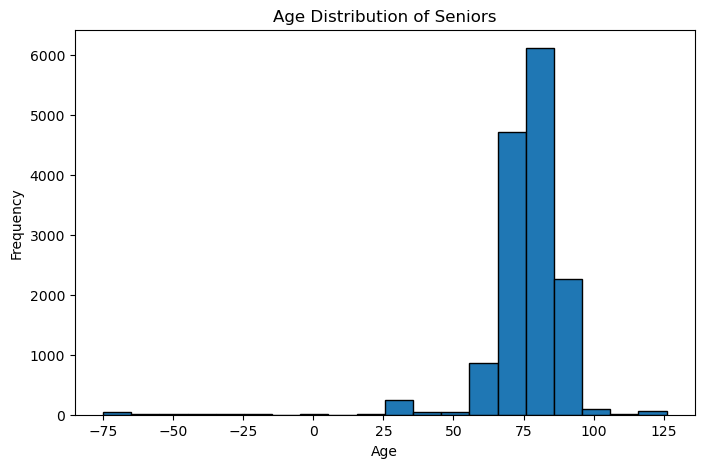

In [125]:
plt.figure(figsize=(8, 5))
plt.hist(seniors_df['age'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Seniors')
plt.show()

In [126]:
seniors_df['birthdate_parsed'] = pd.to_datetime(seniors_df['birthdate'], errors='coerce')
today = pd.Timestamp(date.today())

seniors_df['computed_age'] = ((today - seniors_df['birthdate_parsed']).dt.days / 365.25).round().astype('Int64')
seniors_df['age_discrepancy'] = (seniors_df['computed_age'] - seniors_df['age']).abs()

discrepant = seniors_df[seniors_df['age_discrepancy'] > 1].dropna(subset=['age_discrepancy'])
print(f"Seniors where stored age differs from birthdate-derived age by >1 year: {len(discrepant)}")
if not discrepant.empty:
    print(discrepant[['id', 'birthdate', 'age', 'computed_age', 'age_discrepancy']].head(10).to_string(index=False))

seniors_df.drop(columns=['birthdate_parsed', 'computed_age', 'age_discrepancy'], inplace=True)

Seniors where stored age differs from birthdate-derived age by >1 year: 0


## 2.3 Seniors age outlier analysis

In [127]:
min_age = 60
max_age = 110

age_outliers = seniors_df[(seniors_df['age'] < min_age) | (seniors_df['age'] > max_age)]
print(f"Seniors with age < {min_age}: {len(seniors_df[seniors_df['age'] < min_age])}")
print(f"Seniors with age > {max_age}: {len(seniors_df[seniors_df['age'] > max_age])}")

Seniors with age < 60: 707
Seniors with age > 110: 76


In [128]:
age_outliers[['id', 'gender', 'birthdate', 'age']].head(10)

,id,gender,birthdate,age
26,3289,Female,1970-01-01,56.0
27,3290,Female,1970-01-01,56.0
35,3323,Female,1970-01-01,56.0
106,4788,Female,1966-04-30,59.0
225,7340,Male,1970-01-01,56.0
226,7341,Female,1970-01-01,56.0
227,7343,Female,1970-01-01,56.0
228,7345,Female,1970-01-01,56.0
229,7346,Female,1970-01-01,56.0
230,7348,Female,1970-01-01,56.0


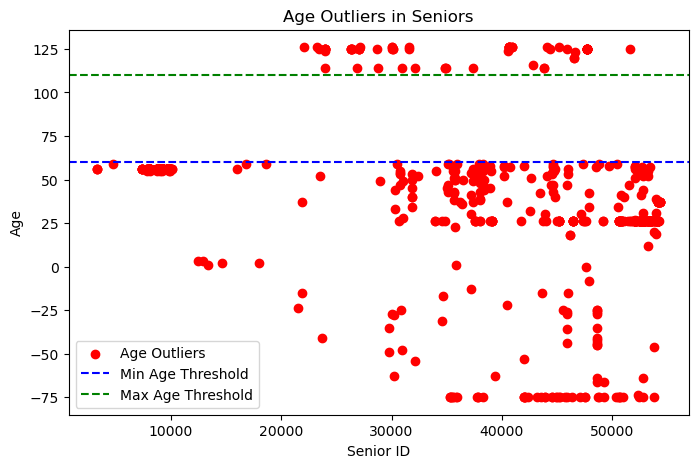

In [129]:
plt.figure(figsize=(8, 5))
plt.scatter(age_outliers['id'], age_outliers['age'], color='red', label='Age Outliers')
plt.axhline(y=min_age, color='blue', linestyle='--', label='Min Age Threshold')
plt.axhline(y=max_age, color='green', linestyle='--', label='Max Age Threshold')
plt.xlabel('Senior ID')
plt.ylabel('Age')
plt.title('Age Outliers in Seniors')
plt.legend()
plt.show()

## 2.4 Seniors with zero measurements

In [17]:
senior_ids_with_measurements = set(
    pd.read_sql_query("SELECT DISTINCT senior_id FROM measurements", conn)['senior_id']
)
seniors_no_measurements = seniors_df[~seniors_df['id'].isin(senior_ids_with_measurements)]
print(f"Seniors with zero measurements: {len(seniors_no_measurements)} "
      f"({len(seniors_no_measurements)/len(seniors_df)*100:.1f}%)")
if not seniors_no_measurements.empty:
    print(seniors_no_measurements[['id', 'gender', 'age']].head(10).to_string(index=False))

Seniors with zero measurements: 0 (0.0%)


# 3. Measurement Volume and Types
Analyze measurement distribution across types and date range.

### 3.1.1 Measurements overview

The following cells contain: measurement type distribution, date range, vital signs analysis, and daily measurements statistics.

In [18]:
query_types = """
    SELECT type, COUNT(*) as count 
    FROM measurements 
    GROUP BY type 
    ORDER BY count DESC
"""
type_counts_df = pd.read_sql_query(query_types, conn)

for _, row in type_counts_df.iterrows():
    percentage = (row['count'] / type_counts_df['count'].sum()) * 100
    print(f"{row['type']:<15}: {row['count']:>12,} ({percentage:.2f}%)")

Heartrate      :   57,764,491 (22.65%)
BloodPressure  :   57,764,420 (22.65%)
Temperature    :   57,534,646 (22.56%)
Saturation     :   46,283,823 (18.15%)
Steps          :   35,671,760 (13.99%)


In [19]:
query_dates = """
    SELECT 
        MIN(date) as min_date, 
        MAX(date) as max_date 
    FROM measurements
"""
dates_df = pd.read_sql_query(query_dates, conn)

min_date = pd.to_datetime(dates_df['min_date'][0])
max_date = pd.to_datetime(dates_df['max_date'][0])

print(f"Min date: {min_date}")
print(f"Max date: {max_date}")
print(f"Total days span: {(max_date - min_date).days} days")

Min date: 2025-11-01 00:00:02
Max date: 2026-01-31 23:59:55
Total days span: 91 days


In [20]:
query_totals = """
    SELECT senior_id, COUNT(*) as total_measurements 
    FROM measurements 
    GROUP BY senior_id
"""
measurements_per_senior_df = pd.read_sql_query(query_totals, conn)

measurements_per_senior = measurements_per_senior_df['total_measurements']

print(f"Average measurements per senior: {measurements_per_senior.mean():.2f}")
print(f"Median measurements per senior: {measurements_per_senior.median():.2f}")
print(f"Min measurements per senior: {measurements_per_senior.min()}")
print(f"Max measurements per senior: {measurements_per_senior.max()}")
print(f"Std dev: {measurements_per_senior.std():.2f}")

Average measurements per senior: 17082.13
Median measurements per senior: 9572.00
Min measurements per senior: 1
Max measurements per senior: 246072
Std dev: 19280.54


In [21]:
query_daily = """
    SELECT senior_id, DATE(date) as day, COUNT(*) as daily_count 
    FROM measurements 
    GROUP BY senior_id, DATE(date)
"""
daily_counts_df = pd.read_sql_query(query_daily, conn)

measurements_per_day_stats = daily_counts_df.groupby('senior_id')['daily_count'].agg(['mean', 'std', 'min', 'max'])

stats = measurements_per_day_stats.reset_index()

display(stats.head(10))

,senior_id,mean,std,min,max
0,2875,316.097826,179.951768,8,659
1,3175,193.261364,94.894920,5,421
2,3176,120.022727,71.995686,10,351
3,3178,22.891304,23.946448,4,88
4,3179,27.142857,20.113961,4,92
5,3183,39.307692,22.410506,4,80
6,3184,47.137931,27.156588,3,101
7,3186,38.875000,22.252037,4,126
8,3188,45.417910,40.945325,2,198
9,3192,139.957746,143.254861,4,474


### 3.1.2 Measurement Plots
The following are plots as in the form of histograms of mean and std across seniors, top 50 seniors by mean measurements/day with error bars for std, and line graph of total measurements per day.

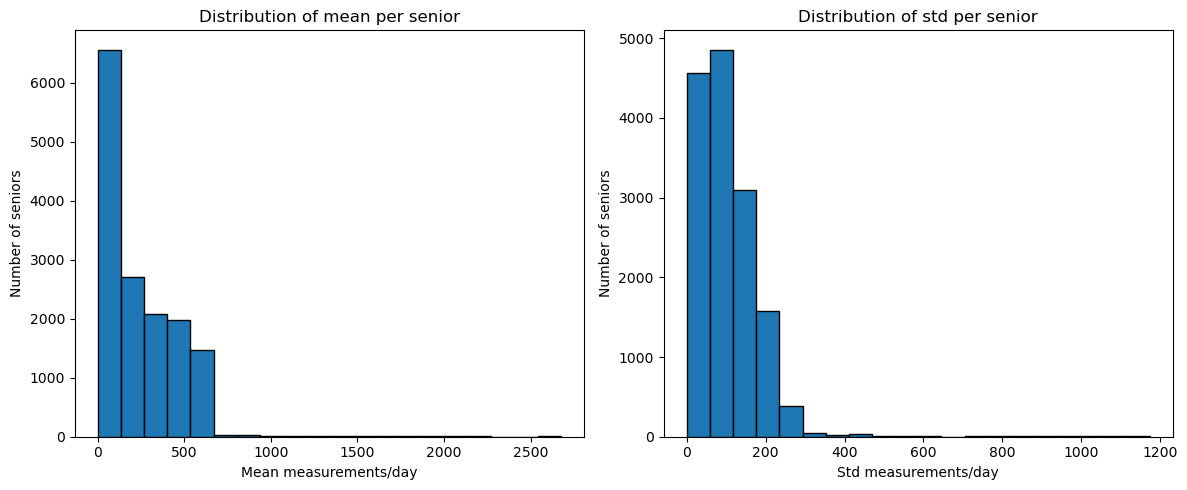

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(stats['mean'].dropna(), bins=20, edgecolor='black')
axes[0].set_xlabel('Mean measurements/day')
axes[0].set_ylabel('Number of seniors')
axes[0].set_title('Distribution of mean per senior')
axes[1].hist(stats['std'].dropna(), bins=20, edgecolor='black')
axes[1].set_xlabel('Std measurements/day')
axes[1].set_ylabel('Number of seniors')
axes[1].set_title('Distribution of std per senior')
plt.tight_layout()
plt.show()

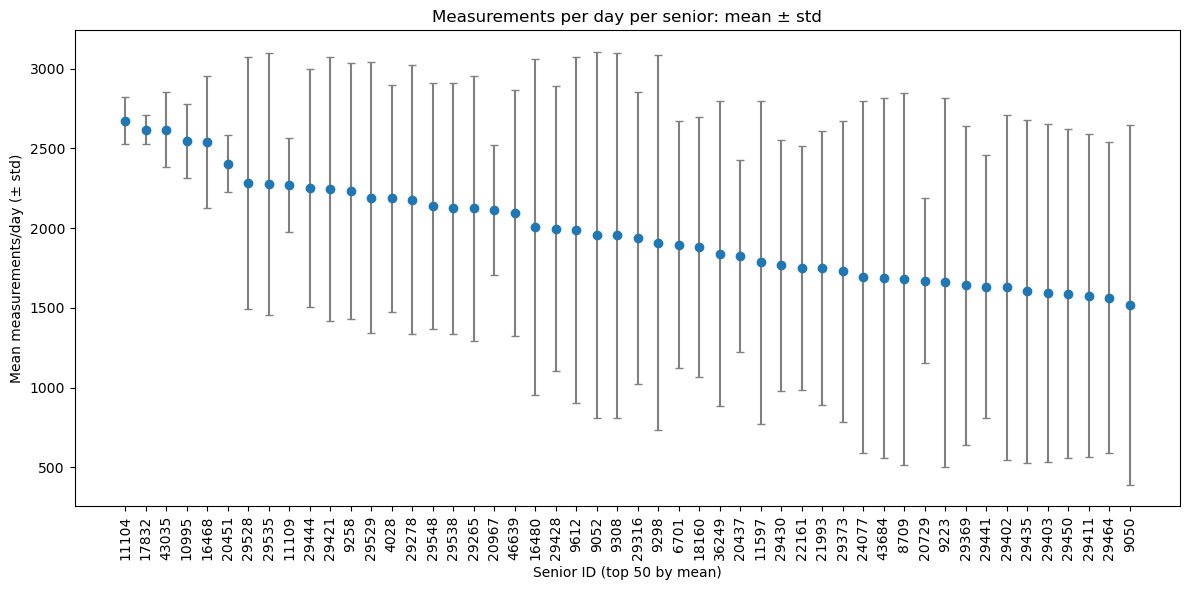

In [23]:
top = stats.sort_values('mean', ascending=False).head(50)
x = np.arange(len(top))
plt.figure(figsize=(12, 6))
plt.errorbar(x, top['mean'], yerr=top['std'], fmt='o', ecolor='gray', capsize=3, color='tab:blue')
plt.xticks(x, top['senior_id'].astype(str), rotation=90)
plt.xlabel('Senior ID (top 50 by mean)')
plt.ylabel('Mean measurements/day (± std)')
plt.title('Measurements per day per senior: mean ± std')
plt.tight_layout()
plt.show()

In [24]:
query = """
    SELECT DATE(date) as day, COUNT(*) as count 
    FROM measurements 
    GROUP BY DATE(date)
"""
daily_counts_df = pd.read_sql_query(query, conn)
daily_counts_df['day'] = pd.to_datetime(daily_counts_df['day'])
daily_counts = daily_counts_df.set_index('day')['count'].sort_index()

full_days = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D')
missing_days = full_days.difference(daily_counts.index)
print(f"Missing days in data: {len(missing_days)}")
print(missing_days[:20])

daily_counts_full = daily_counts.reindex(full_days, fill_value=0)

Missing days in data: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


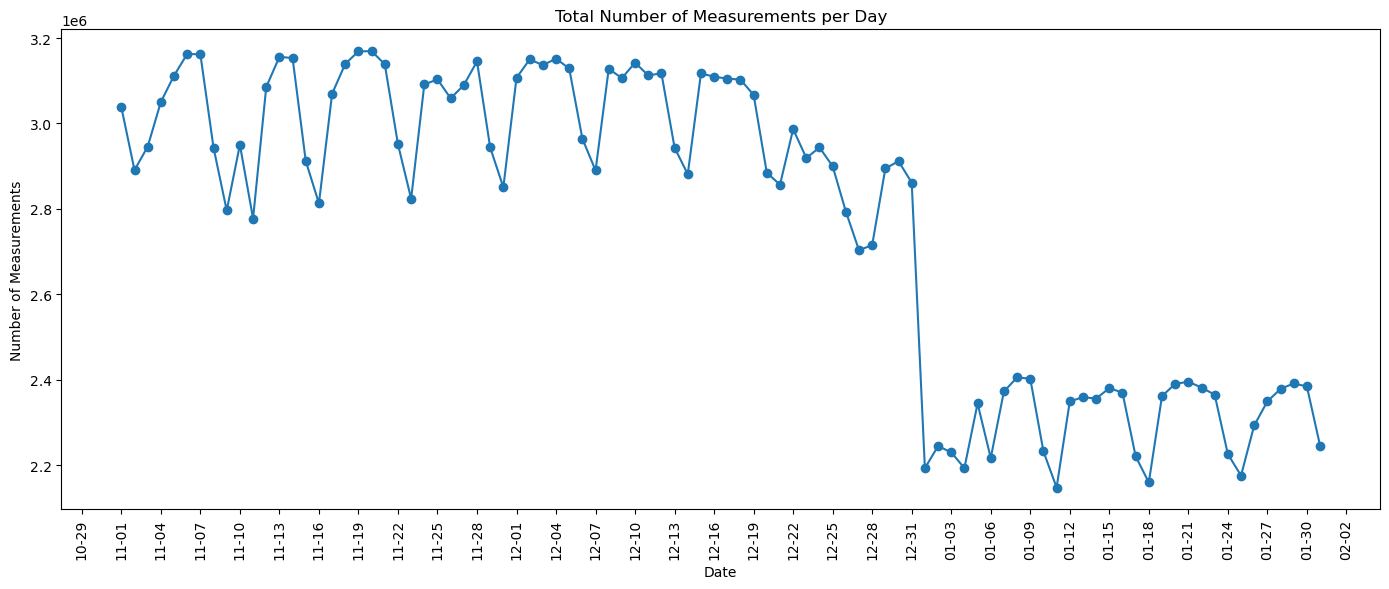

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_counts_full.index, daily_counts_full.values, marker='o', linestyle='-')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.setp(ax.get_xticklabels(), rotation=90)
ax.set_title('Total Number of Measurements per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Measurements')
plt.tight_layout()
plt.show()

## 3.2 Measurement Type Analysis
Analyze vital signs, find outliers, and correlation between types.

In [26]:
# Impossible values checks
temp_min, temp_max = 30, 45
SBP_min, SBP_max = 70, 250
DBP_min, DBP_max = 40, 140
saturation_min = 50
HR_min, HR_max = 30, 220

### 3.2.1 Blood Pressure Statistics

In [27]:
bp_df = pd.read_sql_query("""
    SELECT sbp, dbp 
    FROM measurements 
    WHERE type = 'BloodPressure' AND sbp IS NOT NULL AND dbp IS NOT NULL
""", conn)

In [28]:
print("\nBloodPressure (SBP):")
print(f"  Min: {bp_df['sbp'].min():.2f} | Max: {bp_df['sbp'].max():.2f}")
print(f"  Mean: {bp_df['sbp'].mean():.2f} | Std: {bp_df['sbp'].std():.2f}")

print("\nBloodPressure (DBP):")
print(f"  Min: {bp_df['dbp'].min():.2f} | Max: {bp_df['dbp'].max():.2f}")
print(f"  Mean: {bp_df['dbp'].mean():.2f} | Std: {bp_df['dbp'].std():.2f}")


BloodPressure (SBP):
  Min: 68.00 | Max: 212.00
  Mean: 129.44 | Std: 11.89

BloodPressure (DBP):
  Min: 23.00 | Max: 157.00
  Mean: 78.61 | Std: 8.83


In [29]:
sbp_impossible = len(bp_df[(bp_df['sbp'] > SBP_max) | (bp_df['sbp'] < SBP_min)])
dbp_impossible = len(bp_df[(bp_df['dbp'] > DBP_max) | (bp_df['dbp'] < DBP_min)])
print(f"\nSBP > {SBP_max} or < {SBP_min} mmHg: {sbp_impossible:,}")
print(f"DBP > {DBP_max} or < {DBP_min} mmHg: {dbp_impossible:,}")


SBP > 250 or < 70 mmHg: 1,081
DBP > 140 or < 40 mmHg: 25,022


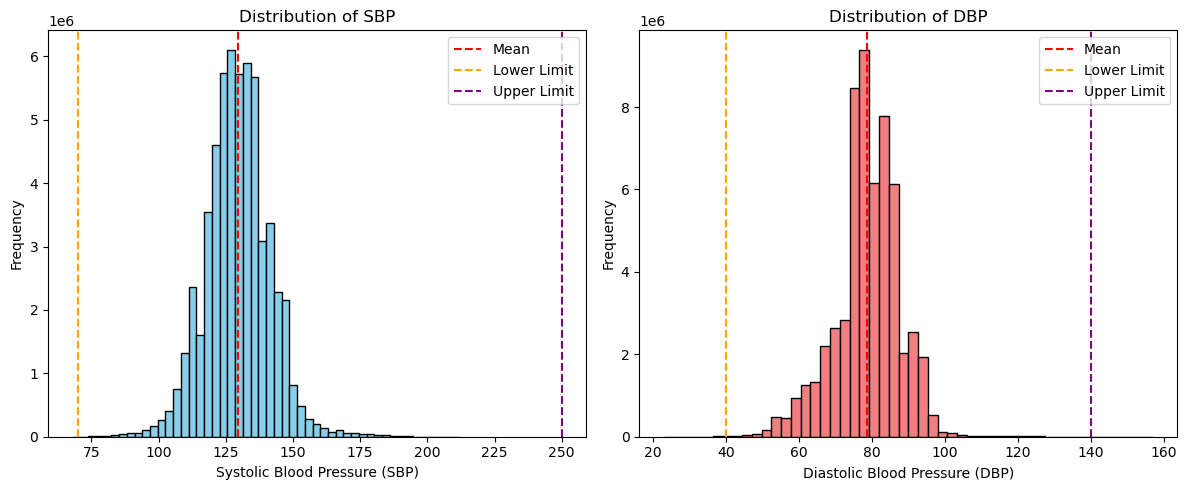

In [30]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(bp_df['sbp'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(bp_df['sbp'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(SBP_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(SBP_max, color='purple', linestyle='dashed', label='Upper Limit')
plt.xlabel('Systolic Blood Pressure (SBP)')
plt.ylabel('Frequency')
plt.title('Distribution of SBP')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(bp_df['dbp'], bins=50, color='lightcoral', edgecolor='black')
plt.axvline(bp_df['dbp'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(DBP_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(DBP_max, color='purple', linestyle='dashed', label='Upper Limit')
plt.xlabel('Diastolic Blood Pressure (DBP)')
plt.ylabel('Frequency')
plt.title('Distribution of DBP')
plt.legend()
plt.tight_layout()
plt.show()

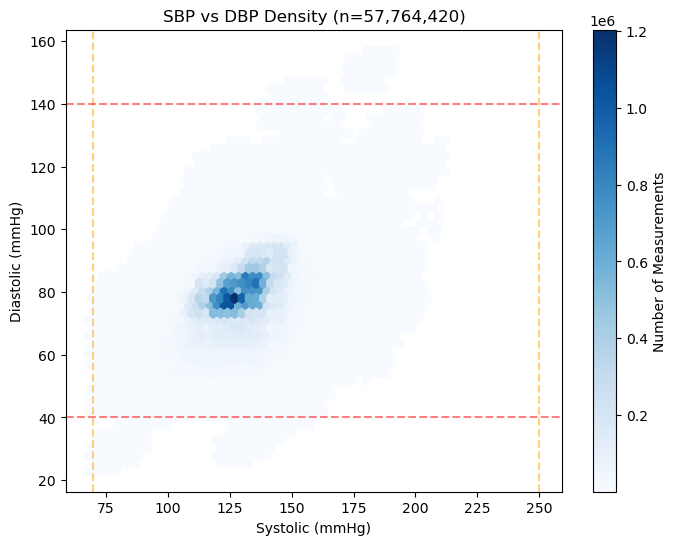

In [31]:
plt.figure(figsize=(8, 6))
hb = plt.hexbin(bp_df['sbp'], bp_df['dbp'], gridsize=50, cmap='Blues', mincnt=1)
cb = plt.colorbar(hb, label='Number of Measurements')
plt.title(f"SBP vs DBP Density (n={len(bp_df):,})")
plt.xlabel("Systolic (mmHg)")
plt.ylabel("Diastolic (mmHg)")
plt.axvline(SBP_min, color='orange', linestyle='dashed', alpha=0.5)
plt.axvline(SBP_max, color='orange', linestyle='dashed', alpha=0.5)
plt.axhline(DBP_min, color='red', linestyle='dashed', alpha=0.5)
plt.axhline(DBP_max, color='red', linestyle='dashed', alpha=0.5)
plt.show()

In [32]:
bp_df_check = pd.read_sql_query("""
    SELECT sbp, dbp FROM measurements
    WHERE type = 'BloodPressure' AND sbp IS NOT NULL AND dbp IS NOT NULL
""", conn)

inverted_bp = bp_df_check[bp_df_check['dbp'] >= bp_df_check['sbp']]
print(f"Readings where DBP >= SBP (impossible): {len(inverted_bp):,} "
      f"({len(inverted_bp)/len(bp_df_check)*100:.2f}%)")

Readings where DBP >= SBP (impossible): 11,128 (0.02%)


In [33]:
del bp_df, bp_df_check
gc.collect()

7

### 3.2.2 Temperature Statistics

In [34]:
df = pd.read_sql_query("SELECT value FROM measurements WHERE type = 'Temperature'", conn)

In [35]:
print(f"  Min: {df['value'].min():.2f} | Max: {df['value'].max():.2f}")
print(f"  Mean: {df['value'].mean():.2f} | Std: {df['value'].std():.2f}")

  Min: 36.20 | Max: 127.90
  Mean: 36.68 | Std: 2.62


In [36]:
imp = len(df[(df['value'] > temp_max) | (df['value'] < temp_min)])
print(f"  Impossible (> {temp_max} or < {temp_min} °C): {imp:,}")

  Impossible (> 45 or < 30 °C): 49,435


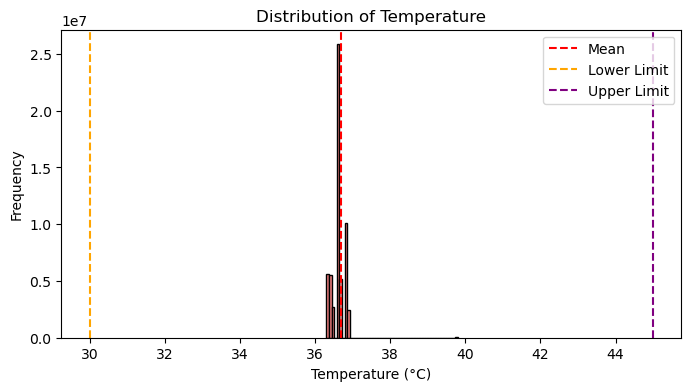

In [37]:
plt.figure(figsize=(8, 4))
plot_data = df['value'].clip(lower=df['value'].quantile(0.001), upper=df['value'].quantile(0.999))
plt.hist(plot_data, bins=50, color='lightcoral', edgecolor='black')
plt.axvline(df['value'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(temp_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(temp_max, color='purple', linestyle='dashed', label='Upper Limit')

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.legend()
plt.show()

In [38]:
del df
del plot_data
gc.collect()

6409

### 3.2.3 Heart Rate Statistics

In [39]:
df = pd.read_sql_query("SELECT value FROM measurements WHERE type = 'Heartrate'", conn)

In [40]:
print(f"  Min: {df['value'].min():.2f} | Max: {df['value'].max():.2f}")
print(f"  Mean: {df['value'].mean():.2f} | Std: {df['value'].std():.2f}")

  Min: 1.00 | Max: 214.00
  Mean: 73.31 | Std: 17.73


In [41]:
imp = len(df[(df['value'] > HR_max) | (df['value'] < HR_min)])
print(f"  Impossible (> {HR_max} or < {HR_min} bpm): {imp:,}")

  Impossible (> 220 or < 30 bpm): 20


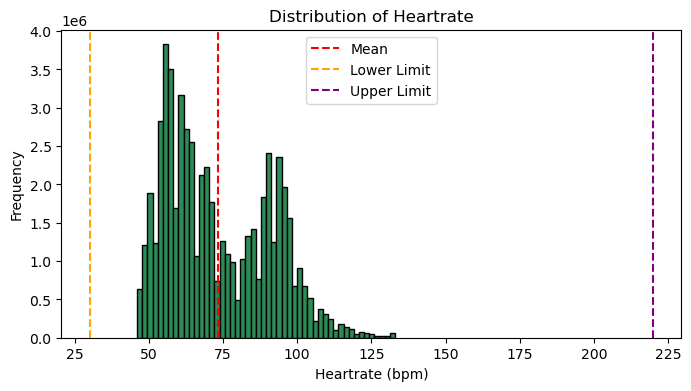

In [42]:
plt.figure(figsize=(8, 4))
plot_data = df['value'].clip(lower=df['value'].quantile(0.001), upper=df['value'].quantile(0.999))
plt.hist(plot_data, bins=50, color='seagreen', edgecolor='black')
plt.axvline(df['value'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(HR_min, color='orange', linestyle='dashed', label='Lower Limit')
plt.axvline(HR_max, color='purple', linestyle='dashed', label='Upper Limit')

plt.xlabel('Heartrate (bpm)')
plt.ylabel('Frequency')
plt.title('Distribution of Heartrate')
plt.legend()
plt.show()

In [43]:
del df
del plot_data
gc.collect()

6805

### 3.2.4 Saturation (SpO2) Statistics

In [44]:
df = pd.read_sql_query("SELECT value FROM measurements WHERE type = 'Saturation'", conn)

In [45]:
print(f"  Min: {df['value'].min():.2f} | Max: {df['value'].max():.2f}")
print(f"  Mean: {df['value'].mean():.2f} | Std: {df['value'].std():.2f}")

  Min: 80.00 | Max: 100.00
  Mean: 97.06 | Std: 3.31


In [46]:
imp = len(df[df['value'] < saturation_min])
print(f"  Impossible (< {saturation_min} %): {imp:,}")

  Impossible (< 50 %): 0


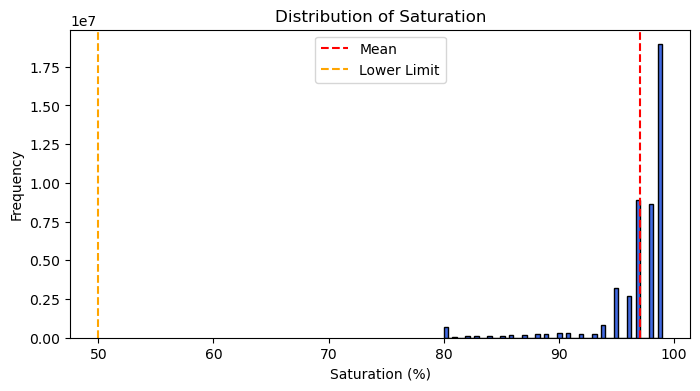

In [47]:
plt.figure(figsize=(8, 4))
plot_data = df['value'].clip(lower=df['value'].quantile(0.001), upper=df['value'].quantile(0.999))
plt.hist(plot_data, bins=50, color='royalblue', edgecolor='black')
plt.axvline(df['value'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(saturation_min, color='orange', linestyle='dashed', label='Lower Limit')

plt.xlabel('Saturation (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Saturation')
plt.legend()
plt.show()

In [48]:
del df
del plot_data
gc.collect()

6164

### 3.2.5 Steps Statistics

In [49]:
df = pd.read_sql_query("SELECT value FROM measurements WHERE type = 'Steps'", conn)

In [50]:
print(f"  Min: {df['value'].min():.2f} | Max: {df['value'].max():.2f}")
print(f"  Mean: {df['value'].mean():.2f} | Std: {df['value'].std():.2f}")

  Min: 1.00 | Max: 50147.00
  Mean: 2980.79 | Std: 3036.75


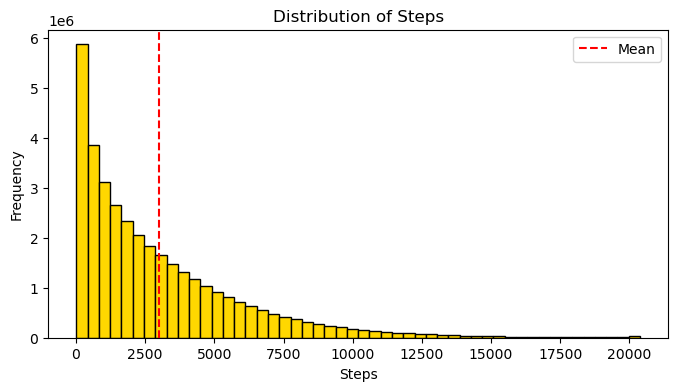

In [51]:
plt.figure(figsize=(8, 4))
plot_data = df['value'].clip(lower=df['value'].quantile(0.001), upper=df['value'].quantile(0.999))
plt.hist(plot_data, bins=50, color='gold', edgecolor='black')
plt.axvline(df['value'].mean(), color='red', linestyle='dashed', label='Mean')

plt.xlabel('Steps')
plt.ylabel('Frequency')
plt.title('Distribution of Steps')
plt.legend()
plt.show()

In [52]:
del df
del plot_data
gc.collect()

6273

### 3.2.6 Create wide-format DataFrame

We use DuckDB since the table size is too big.

In [171]:
con = duckdb.connect()

con.execute("INSTALL sqlite;")
con.execute("LOAD sqlite;")

con.execute("CALL sqlite_attach('../db/hrp_data.db');")

In [59]:
query = """
    SELECT 
        senior_id, 
        CAST(date AS DATE) AS day,
        type,
        AVG(value) as mean_value,
        SUM(value) as sum_value,
        AVG(sbp) as mean_sbp,
        AVG(dbp) as mean_dbp
    FROM measurements
    GROUP BY senior_id, CAST(date AS DATE), type
"""

daily_vitals_df = con.execute(query).df()

In [60]:
len(daily_vitals_df)

4239107

In [61]:
hr = daily_vitals_df[daily_vitals_df['type'] == 'Heartrate'].set_index(['senior_id', 'day'])['mean_value'].rename('Heartrate')
temp = daily_vitals_df[daily_vitals_df['type'] == 'Temperature'].set_index(['senior_id', 'day'])['mean_value'].rename('Temperature')
sat = daily_vitals_df[daily_vitals_df['type'] == 'Saturation'].set_index(['senior_id', 'day'])['mean_value'].rename('Saturation')
steps = daily_vitals_df[daily_vitals_df['type'] == 'Steps'].set_index(['senior_id', 'day'])['sum_value'].rename('Steps')
sbp = daily_vitals_df[daily_vitals_df['type'] == 'BloodPressure'].set_index(['senior_id', 'day'])['mean_sbp'].rename('SBP')
dbp = daily_vitals_df[daily_vitals_df['type'] == 'BloodPressure'].set_index(['senior_id', 'day'])['mean_dbp'].rename('DBP')

wide_df = pd.concat([hr, temp, sat, steps, sbp, dbp], axis=1).reset_index()

In [62]:
wide_df.shape

(914682, 8)

In [ ]:
del daily_vitals_df
gc.collect()

2314

### 3.2.7 Daily Correlation matrix of vital signs

In [64]:
corr_matrix = wide_df[['Heartrate', 'Temperature', 'Saturation', 'Steps', 'SBP', 'DBP']].corr()
print(corr_matrix)

             Heartrate  Temperature  Saturation     Steps       SBP       DBP
Heartrate     1.000000    -0.007099    0.608710  0.098538  0.181942  0.176443
Temperature  -0.007099     1.000000   -0.007220 -0.002516 -0.003386  0.001710
Saturation    0.608710    -0.007220    1.000000 -0.040507  0.091321  0.087978
Steps         0.098538    -0.002516   -0.040507  1.000000  0.000468  0.020005
SBP           0.181942    -0.003386    0.091321  0.000468  1.000000  0.401972
DBP           0.176443     0.001710    0.087978  0.020005  0.401972  1.000000


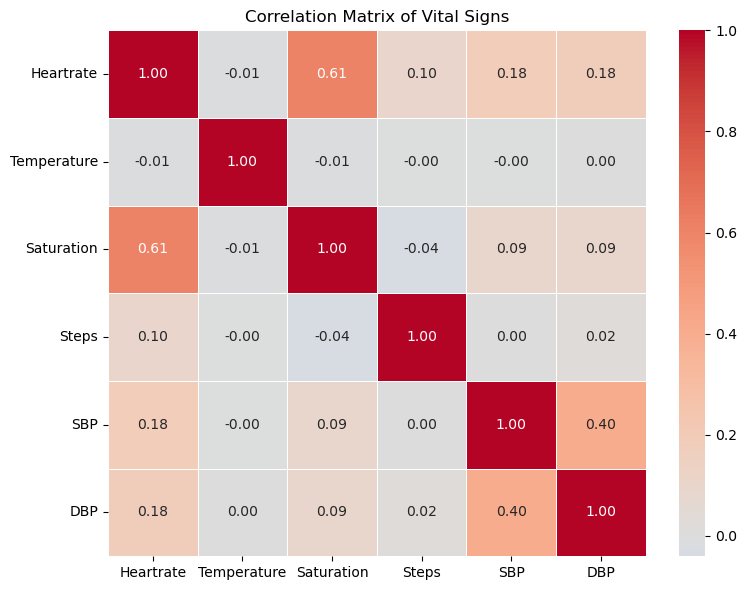

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Vital Signs")
plt.tight_layout()
plt.show()

### 3.2.8 Time-Shifted Correlation matrix of vital signs

In [199]:
query = """
    WITH target_seniors AS (
        SELECT DISTINCT senior_id 
        FROM alerts 
        WHERE LOWER(sos_note) LIKE 'alarm. nawiązano kontakt z seniorem.%' 
           OR LOWER(sos_note) LIKE 'alarm. nie nawiązano kontaktu z seniorem i opiekunem.%'
        LIMIT 50
    )
    SELECT 
        m.senior_id,
        time_bucket(INTERVAL '5 minutes', CAST(m.date AS TIMESTAMP)) as time_bucket,
        AVG(CASE WHEN m.type = 'Heartrate' THEN m.value END) AS HR,
        AVG(CASE WHEN m.type = 'BloodPressure' THEN m.sbp END) AS SBP,
        AVG(CASE WHEN m.type = 'BloodPressure' THEN m.dbp END) AS DBP,
        AVG(CASE WHEN m.type = 'Saturation' THEN m.value END) AS SpO2,
        SUM(CASE WHEN m.type = 'Steps' THEN m.value END) AS Steps
    FROM measurements m
    JOIN target_seniors t ON m.senior_id = t.senior_id
    GROUP BY m.senior_id, time_bucket
    ORDER BY m.senior_id, time_bucket
"""

ts_df = con.execute(query).df()

In [200]:
len(ts_df)

318514

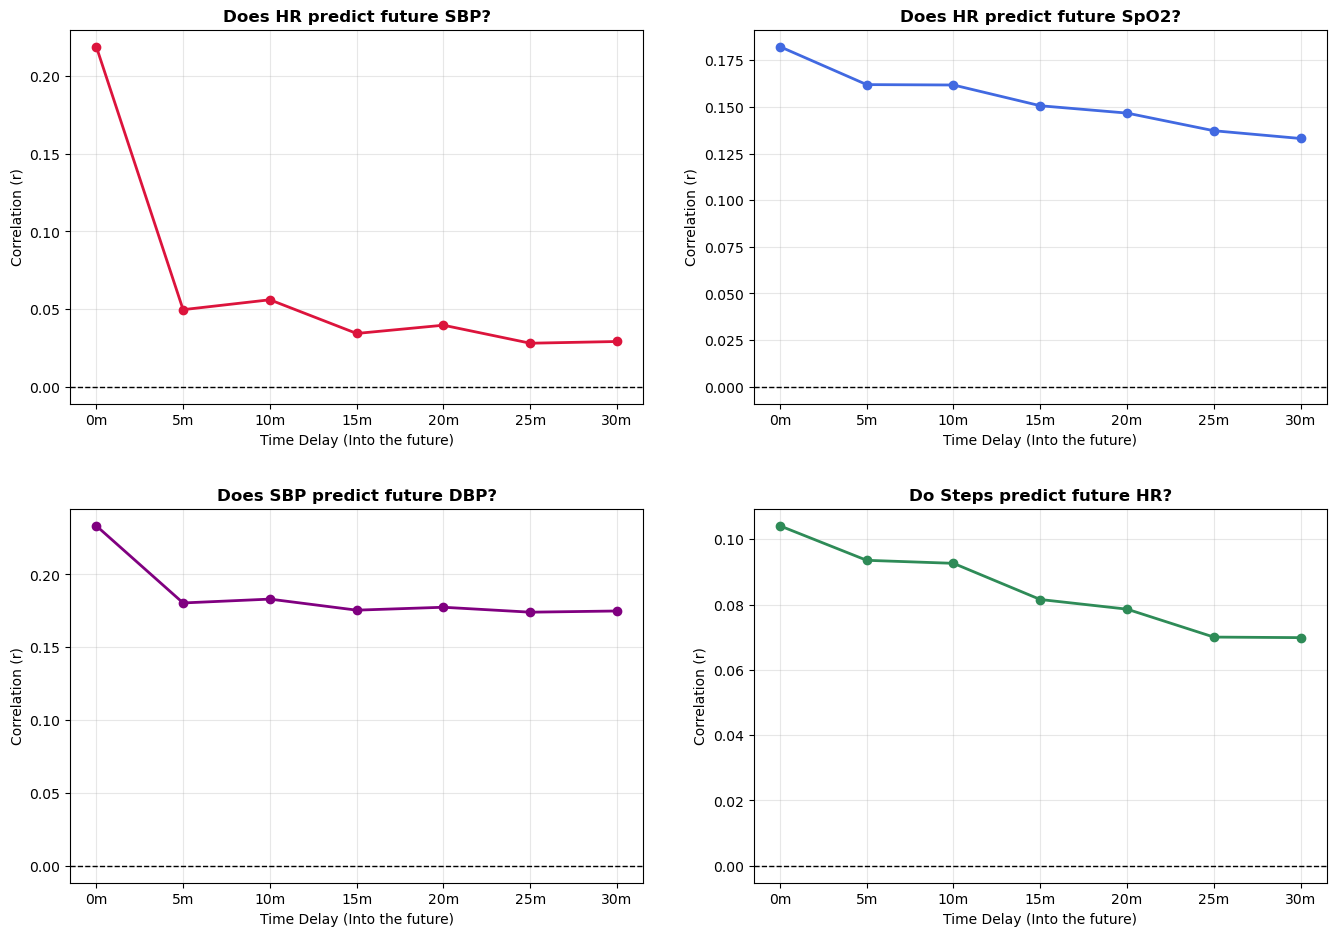

In [ ]:
shifts = [0, 1, 2, 3, 4, 5, 6]
shift_labels = ['0m', '5m', '10m', '15m', '20m', '25m', '30m']

pairs_to_test = [
    ('HR', 'SBP', "Does HR predict future SBP?", 'crimson'),
    ('HR', 'SpO2', "Does HR predict future SpO2?", 'royalblue'),
    ('SBP', 'DBP', "Does SBP predict future DBP?", 'purple'),
    ('Steps', 'HR', "Do Steps predict future HR?", 'seagreen')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (lead, lag, title, color) in enumerate(pairs_to_test):
    correlations = []
    
    for shift in shifts:
        shifted_lag = ts_df.groupby('senior_id')[lag].shift(-shift)
        
        valid_idx = ts_df[lead].notna() & shifted_lag.notna()
        
        if valid_idx.sum() > 30:
            corr = ts_df.loc[valid_idx, lead].corr(shifted_lag.loc[valid_idx])
        else:
            corr = 0
            
        correlations.append(corr)
    
    ax = axes[i]
    ax.plot(shift_labels, correlations, marker='o', linestyle='-', color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Time Delay (Into the future)")
    ax.set_ylabel("Correlation (r)")
    ax.grid(alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

# 4. Medical History Linkage

Analyze disease and medication coverage.

## 4.1 Load disease and medicine data

In [66]:
diseases_df = pd.read_sql_query("SELECT * FROM senior_diseases", conn)
medicines_df = pd.read_sql_query("SELECT * FROM senior_medicines", conn)
diseases_lookup = pd.read_sql_query("SELECT * FROM diseases", conn)
medicines_lookup = pd.read_sql_query("SELECT * FROM medicines", conn)

## 4.2 Disease linkage

In [67]:
seniors_with_disease = diseases_df['senior_id'].nunique()
disease_coverage = seniors_with_disease / total_seniors * 100
print(f"Seniors with at least one disease: {seniors_with_disease} ({disease_coverage:.2f}%)")
print(f"Total disease records: {len(diseases_df)}")
print(f"Avg diseases per senior (with diseases): {len(diseases_df) / seniors_with_disease:.2f}")

Seniors with at least one disease: 9129 (61.15%)
Total disease records: 55383
Avg diseases per senior (with diseases): 6.07


## 4.3 Medication linkage

In [68]:
seniors_with_medicine = medicines_df['senior_id'].nunique()
medicine_coverage = seniors_with_medicine / total_seniors * 100
print(f"Seniors with at least one medication: {seniors_with_medicine} ({medicine_coverage:.2f}%)")
print(f"Total medication records: {len(medicines_df)}")
print(f"Avg medications per senior (with meds): {len(medicines_df) / seniors_with_medicine:.2f}")

Seniors with at least one medication: 9129 (61.15%)
Total medication records: 53852
Avg medications per senior (with meds): 5.90


# 5. Alert Analysis

Based on alert notes, analyze and categorize alerts into 4 levels: 

- **Level -1:** Undocumented - Alerts without any notes.
- **Level 0:** Noise/Technical - Accidental presses or system checks. Keywords include: `przypadkowy`, `testowy`, `techniczny`, `test`
- **Level 1:** Low - Human verified that the senior is (likely) okay. Keywords include: `nawiązano kontakt`, `opiekun powiadomiony`, `brak wskazań do interwencji zrm`
- **Level 2:** Potential/Unknown - No one spoke to the senior. High uncertainty. Keywords include: `nie nawiązano kontaktu`
- **Level 3:** Acute - Highest priority. If these exist, it's a crisis. Keywords include: `interwencja zrm`, `zagrożenia życia i zdrowia`, `zdecydowano wezwać zrm`

## 5.1 Load alerts table into DataFrame

In [183]:
alerts_df = pd.read_sql_query("SELECT * FROM alerts", conn)
alerts_df['alert_date'] = pd.to_datetime(alerts_df['alert_date'], format='ISO8601')

## 5.2 Number of alerts and unique seniors with alerts

In [184]:
total_alerts = len(alerts_df)
unique_seniors_with_alerts = alerts_df['senior_id'].nunique()
print(f"Total alerts: {total_alerts}")
print(f"Unique seniors with alerts: {unique_seniors_with_alerts}")

Total alerts: 14392
Unique seniors with alerts: 6044


In [185]:
alerts_df.head()

,alert_id,senior_id,alert_date,sos_note
0,1,3205,2025-11-30 17:07:51,Alarm przypadkowy
1,2,3221,2025-11-25 19:38:36,Alarm przypadkowy
2,3,3275,2025-11-14 15:01:34,Alarm przypadkowy
3,4,3279,2025-11-09 11:58:31,Alarm przypadkowy
4,5,3283,2025-11-17 18:44:32,Alarm przypadkowy


## 5.3 Classify alerts based on notes 

In [186]:
def classify_severity(note):
    if pd.isna(note):
        return -1

    note_l = str(note).lower()

    if any(k in note_l for k in ['alarm przypadkowy', 'alarm testowy', 'alert techniczny']):
        return 0

    no_zrm = 'brak wskazań do interwencji zrm' in note_l

    if (not no_zrm and (
            'zdecydowano się na interwencję zrm' in note_l or
            'zdecydowano wezwać zrm' in note_l or
            'wezwanie zrm' in note_l or
            (
                'zagrożenia życia i zdrowia' in note_l and
                'nawiązano kontakt' in note_l
            )
            or
            (
                'na podstawie odczytów z systemu' in note_l and
                'zrm' in note_l
            )
        )
    ):
        return 3

    if 'nie nawiązano kontaktu' in note_l:
        return 2

    if ('nawiązano kontakt' in note_l or 'opiekun powiadomiony' in note_l):
        return 1

    return 0

In [187]:
alerts_df['severity'] = alerts_df['sos_note'].apply(classify_severity)

severity_map = {
    -1: "-1: Undocumented",
     0: "0: Noise/Tech",
     1: "1: Low Risk",
     2: "2: Potential/Unknown",
     3: "3: Acute Crisis"
}
alerts_df['severity_label'] = alerts_df['severity'].map(severity_map)


## 5.4 Final severity classification

In [188]:
summary = alerts_df.groupby(['severity_label', 'sos_note']).size().reset_index(name='count')
summary.sort_values('severity_label', ascending=False)

,severity_label,sos_note,count
7,3: Acute Crisis,Alarm. Nawiązano kontakt z Seniorem. W wyniku ...,238
8,3: Acute Crisis,Alarm. Nie nawiązano kontaktu z seniorem i opi...,8
5,2: Potential/Unknown,Alarm. Nie nawiązano kontaktu z Seniorem i opi...,444
6,2: Potential/Unknown,Alarm. Nie nawiązano kontaktu z Seniorem. Opie...,431
3,1: Low Risk,Alarm. Nawiązano kontakt z Seniorem. Opiekun p...,157
4,1: Low Risk,Alarm. Nawiązano kontakt z Seniorem. W wyniku ...,390
0,0: Noise/Tech,Alarm przypadkowy,10148
1,0: Noise/Tech,Alarm testowy,2345
2,0: Noise/Tech,Alert techniczny,104


In [197]:
alerts_df.loc[alerts_df['severity_label'] == '3: Acute Crisis', 'sos_note'].value_counts().head(10)

sos_note
Alarm. Nawiązano kontakt z Seniorem. W wyniku przeprowadzonej oceny stanu pacjenta wykryto sytuację zagrożenia życia i zdrowia. Zdecydowano się na interwencję ZRM.    238
Alarm. Nie nawiązano kontaktu z seniorem i opiekunem. Na podstawie odczytów z systemu zdecydowano wezwać ZRM.                                                            8
Name: count, dtype: int64

## 5.5 Final severity distribution

In [75]:
summary = alerts_df['severity_label'].value_counts().reset_index()
summary.columns = ['severity_label', 'count']
summary['percentage'] = (summary['count'] / summary['count'].sum()) * 100
summary['percentage'] = summary['percentage'].round(2)
summary

,severity_label,count,percentage
0,0: Noise/Tech,12597,87.53
1,2: Potential/Unknown,875,6.08
2,1: Low Risk,547,3.80
3,3: Acute Crisis,246,1.71
4,-1: Undocumented,127,0.88


# 6. Duplicate Analysis

## 6.1 Duplicate `measurements` Table

### 6.1.1 Find measurements with the same senior_id, date, and type.

In [133]:
con.execute("""
    CREATE OR REPLACE TEMP TABLE duplicate_groups AS
    SELECT 
        senior_id, 
        date, 
        type, 
        COUNT(*) as row_count,
        MIN(value) as min_val,
        MAX(value) as max_val,
        MIN(sbp) as min_sbp,
        MAX(sbp) as max_sbp,
        MIN(dbp) as min_dbp,
        MAX(dbp) as max_dbp
    FROM measurements
    GROUP BY senior_id, date, type
    HAVING COUNT(*) > 1;
""")

total_measurements = con.execute("SELECT COUNT(*) FROM measurements").fetchone()[0]
total_dup_groups = con.execute("SELECT COUNT(*) FROM duplicate_groups").fetchone()[0]
total_dup_rows = con.execute("SELECT SUM(row_count) FROM duplicate_groups").fetchone()[0]

total_dup_rows = total_dup_rows if total_dup_rows else 0

print(f"Total measurement rows: {total_measurements:,}")
print(f"Groups with duplicates (same senior_id, date, type): {total_dup_groups:,}")
print(f"Total duplicate measurement rows: {total_dup_rows:,}")
print(f"Percentage of measurements that are duplicates: {(total_dup_rows/total_measurements*100):.2f}%")

Total measurement rows: 255,019,140
Groups with duplicates (same senior_id, date, type): 2,575
Total duplicate measurement rows: 5,156
Percentage of measurements that are duplicates: 0.00%


### 6.1.2 True vs Conflicting duplicates

Analyze whether duplicates have the same value (true duplicates) or different values (conflicting data).

In [134]:
query_classification = """
    SELECT 
        SUM(CASE 
            WHEN type = 'BloodPressure' THEN 
                CASE WHEN min_sbp = max_sbp AND min_dbp = max_dbp THEN 1 ELSE 0 END
            ELSE 
                CASE WHEN min_val = max_val THEN 1 ELSE 0 END
        END) as true_duplicates,
        
        SUM(CASE 
            WHEN type = 'BloodPressure' THEN 
                CASE WHEN min_sbp != max_sbp OR min_dbp != max_dbp THEN 1 ELSE 0 END
            ELSE 
                CASE WHEN min_val != max_val THEN 1 ELSE 0 END
        END) as conflicting_duplicates
    FROM duplicate_groups;
"""

result = con.execute(query_classification).fetchone()
true_dups = result[0] if result[0] else 0
conflicting_dups = result[1] if result[1] else 0

print(f"Total Duplicate Groups: {total_dup_groups:,}")
print(f"True Duplicates (Exact matches): {true_dups:,}")
print(f"Conflicting Duplicates (Different values): {conflicting_dups:,}")

Total Duplicate Groups: 2,575
True Duplicates (Exact matches): 391
Conflicting Duplicates (Different values): 2,184


### 6.1.3 Duplicates by measurement type

Analyze which measurement types have the most duplicates.

In [135]:
query_type_summary = """
    SELECT 
        type,
        SUM(row_count) as total_duplicate_rows,
        COUNT(*) as total_groups,
        SUM(CASE 
            WHEN type = 'BloodPressure' THEN 
                CASE WHEN min_sbp = max_sbp AND min_dbp = max_dbp THEN 1 ELSE 0 END
            ELSE 
                CASE WHEN min_val = max_val THEN 1 ELSE 0 END
        END) as true_duplicate_groups,
        SUM(CASE 
            WHEN type = 'BloodPressure' THEN 
                CASE WHEN min_sbp != max_sbp OR min_dbp != max_dbp THEN 1 ELSE 0 END
            ELSE 
                CASE WHEN min_val != max_val THEN 1 ELSE 0 END
        END) as conflicting_groups
    FROM duplicate_groups
    GROUP BY type
    ORDER BY total_duplicate_rows DESC;
"""

type_summary_df = con.execute(query_type_summary).df()
display(type_summary_df)

,type,total_duplicate_rows,total_groups,true_duplicate_groups,conflicting_groups
0,Heartrate,2039.0,1018,159.0,859.0
1,BloodPressure,2011.0,1004,5.0,999.0
2,Temperature,668.0,334,136.0,198.0
3,Saturation,410.0,205,89.0,116.0
4,Steps,28.0,14,2.0,12.0


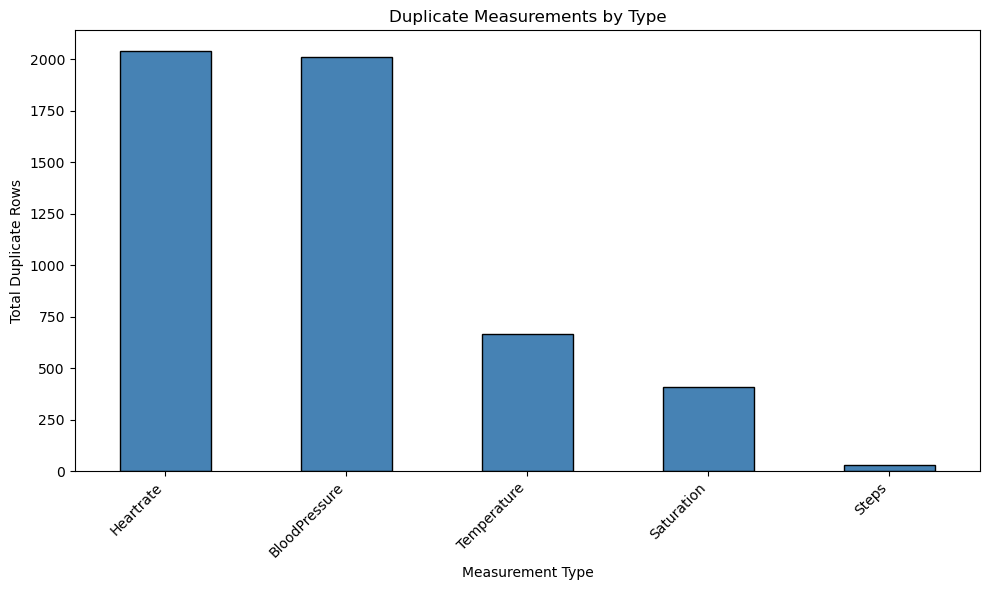

In [136]:
if type_summary_df.empty:
    print("The UNIQUE(senior_id, date, type) database constraint is working perfectly.")
else:
    plt.figure(figsize=(10, 6))
    type_summary_df.set_index('type')['total_duplicate_rows'].plot(kind='bar', color='steelblue', edgecolor='black')
    
    plt.xlabel('Measurement Type')
    plt.ylabel('Total Duplicate Rows')
    plt.title('Duplicate Measurements by Type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 6.1.4 Example duplicate entries

Display sample duplicate entries for review.

In [137]:
query_true = """
    WITH target_groups AS (
        SELECT senior_id, date, type
        FROM duplicate_groups
        WHERE (type != 'BloodPressure' AND min_val = max_val)
           OR (type = 'BloodPressure' AND min_sbp = max_sbp AND min_dbp = max_dbp)
        LIMIT 3
    )
    SELECT m.senior_id, m.date, m.type, m.value, m.sbp, m.dbp
    FROM measurements m
    JOIN target_groups t 
      ON m.senior_id = t.senior_id 
     AND m.date = t.date 
     AND m.type = t.type
    ORDER BY m.senior_id, m.date, m.type;
"""
true_examples_df = con.execute(query_true).df()

if true_examples_df.empty:
    print("No True Duplicates found.")
else:
    for (sid, d, t), group in true_examples_df.groupby(['senior_id', 'date', 'type']):
        print(f"\nGroup: Senior {sid} | Date: {d} | Type: {t}")
        if t == 'BloodPressure':
            print(group[['senior_id', 'date', 'type', 'sbp', 'dbp']].to_string(index=False))
        else:
            print(group[['senior_id', 'date', 'type', 'value']].to_string(index=False))


Group: Senior 7943 | Date: 2025-12-07 07:09:10 | Type: Heartrate
 senior_id                date      type  value
      7943 2025-12-07 07:09:10 Heartrate   51.0
      7943 2025-12-07 07:09:10 Heartrate   51.0

Group: Senior 20150 | Date: 2025-12-18 10:03:24 | Type: Temperature
 senior_id                date        type  value
     20150 2025-12-18 10:03:24 Temperature   36.6
     20150 2025-12-18 10:03:24 Temperature   36.6

Group: Senior 45456 | Date: 2025-11-06 13:07:11 | Type: Temperature
 senior_id                date        type  value
     45456 2025-11-06 13:07:11 Temperature   36.6
     45456 2025-11-06 13:07:11 Temperature   36.6


In [138]:
query_conflict = """
    WITH target_groups AS (
        SELECT senior_id, date, type
        FROM duplicate_groups
        WHERE (type != 'BloodPressure' AND min_val != max_val)
           OR (type = 'BloodPressure' AND (min_sbp != max_sbp OR min_dbp != max_dbp))
        LIMIT 3
    )
    SELECT m.senior_id, m.date, m.type, m.value, m.sbp, m.dbp
    FROM measurements m
    JOIN target_groups t 
      ON m.senior_id = t.senior_id 
     AND m.date = t.date 
     AND m.type = t.type
    ORDER BY m.senior_id, m.date, m.type;
"""
conflict_examples_df = con.execute(query_conflict).df()

if conflict_examples_df.empty:
    print("No Conflicting Duplicates found.")
else:
    for (sid, d, t), group in conflict_examples_df.groupby(['senior_id', 'date', 'type']):
        print(f"\nGroup: Senior {sid} | Date: {d} | Type: {t}")
        if t == 'BloodPressure':
            print(group[['senior_id', 'date', 'type', 'sbp', 'dbp']].to_string(index=False))
        else:
            print(group[['senior_id', 'date', 'type', 'value']].to_string(index=False))


Group: Senior 38591 | Date: 2025-11-11 13:45:11 | Type: BloodPressure
 senior_id                date          type   sbp  dbp
     38591 2025-11-11 13:45:11 BloodPressure 120.0 75.0
     38591 2025-11-11 13:45:11 BloodPressure 124.0 79.0

Group: Senior 44964 | Date: 2026-01-18 07:50:16 | Type: Heartrate
 senior_id                date      type  value
     44964 2026-01-18 07:50:16 Heartrate   70.0
     44964 2026-01-18 07:50:16 Heartrate   74.0

Group: Senior 45456 | Date: 2025-11-06 17:37:11 | Type: BloodPressure
 senior_id                date          type   sbp  dbp
     45456 2025-11-06 17:37:11 BloodPressure 137.0 74.0
     45456 2025-11-06 17:37:11 BloodPressure 128.0 64.0


## 6.2 Duplicate `alerts` Table

### 6.2.1 Temporal Burst Analysis

Find cases where the same senior has multiple alerts within 10 minutes of each other. These may need to be merged into single 'Events' for ML modeling.

In [139]:
burst_threshold_minutes = 10
# TODO: Consider event_size as a feature (number of alerts in burst)

alerts_sorted = alerts_df.sort_values(['senior_id', 'alert_date']).reset_index(drop=True)
alerts_sorted['time_diff'] = alerts_sorted.groupby('senior_id')['alert_date'].diff()
alerts_sorted['time_diff_minutes'] = alerts_sorted['time_diff'].dt.total_seconds() / 60

In [140]:
alerts_sorted.describe()

,alert_id,senior_id,alert_date,severity,hour,time_diff,time_diff_minutes
count,14392.000000,14392.000000,14392,14392.000000,14392.000000,8348,8348.000000
mean,7196.500000,41588.697749,2025-12-13 16:57:32.811839744,0.202057,12.505420,11 days 11:21:21.495567800,16521.358259
min,1.000000,3176.000000,2025-11-01 00:26:14,-1.000000,0.000000,0 days 00:00:00,0.000000
25%,3598.750000,35113.000000,2025-11-20 10:26:12.249999872,0.000000,10.000000,0 days 10:19:31.750000,619.529167
50%,7196.500000,46387.500000,2025-12-11 11:39:00,0.000000,12.000000,5 days 02:47:32.500000,7367.541667
75%,10794.250000,51112.000000,2026-01-06 01:42:06.249999872,0.000000,16.000000,16 days 10:43:23,23683.383333
max,14392.000000,54273.000000,2026-01-31 22:52:54,3.000000,23.000000,85 days 06:32:49,122792.816667
std,4154.756872,11996.129208,NaN,0.634869,4.949257,15 days 06:29:27.576470519,21989.459608


In [141]:
print(f"Total alerts: {len(alerts_sorted):,}")
print("Time difference statistics (minutes):")
print(alerts_sorted['time_diff_minutes'].describe())

Total alerts: 14,392
Time difference statistics (minutes):
count      8348.000000
mean      16521.358259
std       21989.459608
min           0.000000
25%         619.529167
50%        7367.541667
75%       23683.383333
max      122792.816667
Name: time_diff_minutes, dtype: float64


In [142]:
alerts_sorted['is_burst'] = (alerts_sorted['time_diff_minutes'] <= burst_threshold_minutes) & (alerts_sorted['time_diff_minutes'].notna())

burst_alerts = alerts_sorted[alerts_sorted['is_burst']]
total_burst_alerts = len(burst_alerts)
burst_percentage = (total_burst_alerts / len(alerts_sorted)) * 100

print(f"\nAlerts within {burst_threshold_minutes} minutes of previous alert (same senior): {total_burst_alerts:,}")
print(f"Percentage of all alerts: {burst_percentage:.2f}%")


Alerts within 10 minutes of previous alert (same senior): 1,206
Percentage of all alerts: 8.38%


### 6.2.2 Temporal Bursts by Severity Level

In [143]:
burst_by_severity = burst_alerts.groupby('severity_label').size().reset_index(name='burst_count')
burst_by_severity = burst_by_severity.sort_values('burst_count', ascending=False)

severity_totals = alerts_sorted.groupby('severity_label').size().reset_index(name='total_count')
burst_summary = burst_by_severity.merge(severity_totals, on='severity_label')
burst_summary['burst_percentage'] = (burst_summary['burst_count'] / burst_summary['total_count'] * 100).round(2)

burst_summary

,severity_label,burst_count,total_count,burst_percentage
0,0: Noise/Tech,915,12597,7.26
1,2: Potential/Unknown,147,875,16.80
2,1: Low Risk,73,547,13.35
3,3: Acute Crisis,40,246,16.26
4,-1: Undocumented,31,127,24.41


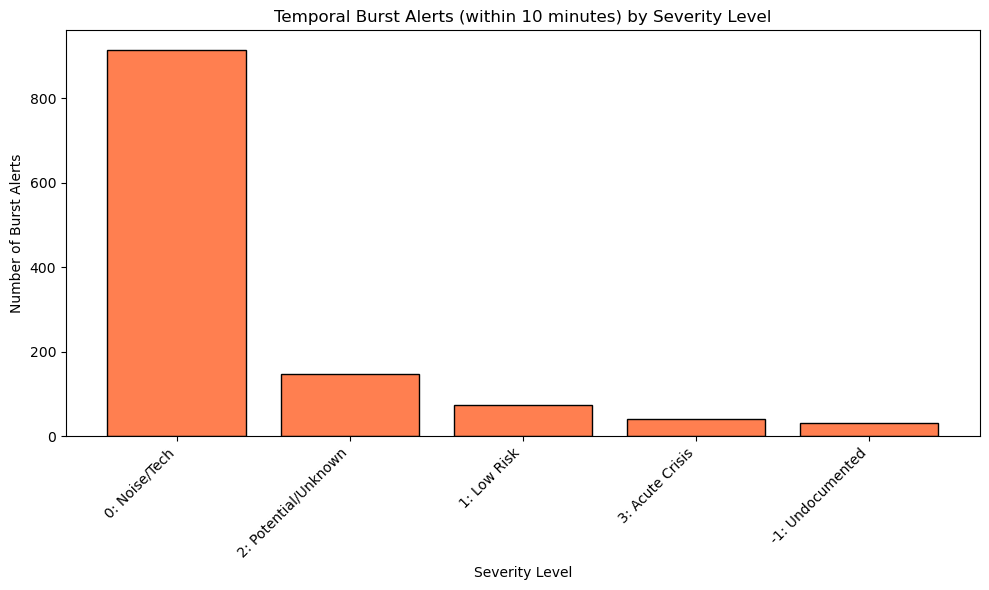

In [144]:
plt.figure(figsize=(10, 6))
plt.bar(burst_summary['severity_label'], burst_summary['burst_count'], color='coral', edgecolor='black')
plt.xlabel('Severity Level')
plt.ylabel('Number of Burst Alerts')
plt.title(f'Temporal Burst Alerts (within {burst_threshold_minutes} minutes) by Severity Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2.3 Identify Alert Burst Events

Group consecutive alerts within 10 minutes into single events.

In [145]:
alerts_sorted['new_event'] = (~alerts_sorted['is_burst']).astype(int)
alerts_sorted['event_id'] = alerts_sorted.groupby('senior_id')['new_event'].cumsum()

alerts_sorted['unique_event_id'] = alerts_sorted['senior_id'].astype(str) + '_' + alerts_sorted['event_id'].astype(str)

In [146]:
total_events = alerts_sorted['unique_event_id'].nunique()
total_alerts = len(alerts_sorted)
events_with_bursts = alerts_sorted[alerts_sorted.groupby('unique_event_id')['unique_event_id'].transform('count') > 1]['unique_event_id'].nunique()

print(f"Total unique alert events: {total_events:,}")
print(f"Events with multiple alerts (bursts): {events_with_bursts:,}")
print(f"Single-alert events: {total_events - events_with_bursts:,}")
print(f"\nCompression ratio: {total_alerts:,} alerts → {total_events:,} events ({(total_events/total_alerts*100):.1f}%)")

Total unique alert events: 13,186
Events with multiple alerts (bursts): 804
Single-alert events: 12,382

Compression ratio: 14,392 alerts → 13,186 events (91.6%)


In [147]:
alerts_sorted.tail(10)

,alert_id,senior_id,alert_date,sos_note,severity,severity_label,hour,time_diff,time_diff_minutes,is_burst,new_event,event_id,unique_event_id
14382,14385,54257,2026-01-28 16:50:27,Alarm testowy,0,0: Noise/Tech,16,NaT,NaN,False,1,1,54257_1
14383,14384,54257,2026-01-29 14:49:52,Alarm przypadkowy,0,0: Noise/Tech,14,0 days 21:59:25,1319.416667,False,1,2,54257_2
14384,14383,54257,2026-01-29 16:20:02,Alarm przypadkowy,0,0: Noise/Tech,16,0 days 01:30:10,90.166667,False,1,3,54257_3
14385,14389,54258,2026-01-28 16:49:57,Alarm testowy,0,0: Noise/Tech,16,NaT,NaN,False,1,1,54258_1
14386,14388,54258,2026-01-30 21:04:24,Alarm przypadkowy,0,0: Noise/Tech,21,2 days 04:14:27,3134.450000,False,1,2,54258_2
14387,14387,54258,2026-01-30 21:09:00,Alarm przypadkowy,0,0: Noise/Tech,21,0 days 00:04:36,4.600000,True,0,2,54258_2
14388,14386,54258,2026-01-31 13:11:31,Alarm przypadkowy,0,0: Noise/Tech,13,0 days 16:02:31,962.516667,False,1,3,54258_3
14389,14390,54259,2026-01-28 16:49:28,Alarm testowy,0,0: Noise/Tech,16,NaT,NaN,False,1,1,54259_1
14390,14391,54260,2026-01-28 16:48:50,Alarm testowy,0,0: Noise/Tech,16,NaT,NaN,False,1,1,54260_1
14391,14392,54273,2026-01-29 14:42:15,Alarm testowy,0,0: Noise/Tech,14,NaT,NaN,False,1,1,54273_1


In [148]:
event_sizes = alerts_sorted.groupby('unique_event_id').size().reset_index(name='alerts_in_event')

print("\nEvent Size Distribution:")
print("=" * 50)
print(event_sizes['alerts_in_event'].value_counts().sort_index().to_string())
print("=" * 50)
print(f"\nMax alerts in single event: {event_sizes['alerts_in_event'].max()}")
print(f"Mean alerts per event: {event_sizes['alerts_in_event'].mean():.2f}")


Event Size Distribution:
alerts_in_event
1     12382
2       625
3        95
4        38
5        20
6         8
7         7
8         5
9         1
10        1
13        1
16        1
17        1
21        1

Max alerts in single event: 21
Mean alerts per event: 1.09


### 6.2.4 Example Burst Events

Display examples of burst events showing multiple alerts clustered in time.

In [149]:
top_events = event_sizes.nlargest(3, 'alerts_in_event')

print("=" * 80)
print("TOP 3 LARGEST BURST EVENTS")
print("=" * 80)
for _, event in top_events.iterrows():
    event_id = event['unique_event_id']
    event_data = alerts_sorted[alerts_sorted['unique_event_id'] == event_id].sort_values('alert_date')
    
    senior_id = event_data.iloc[0]['senior_id']
    alert_count = event['alerts_in_event']
    first_alert = event_data.iloc[0]['alert_date']
    last_alert = event_data.iloc[-1]['alert_date']
    duration = (last_alert - first_alert).total_seconds() / 60
    severity_levels = event_data['severity_label'].value_counts().to_dict()
    
    print(f"\nEvent ID: {event_id}")
    print(f"  Senior ID: {senior_id}")
    print(f"  Number of alerts: {alert_count}")
    print(f"  Time span: {duration:.1f} minutes")
    print(f"  First alert: {first_alert}")
    print(f"  Last alert: {last_alert}")
    print(f"  Severity distribution: {severity_levels}")
    print("  Alert details:")
    for idx, row in event_data.iterrows():
        print(f"    - {row['alert_date']} | {row['severity_label']} | {row['sos_note'][:50] if pd.notna(row['sos_note']) else 'N/A'}...")

TOP 3 LARGEST BURST EVENTS

Event ID: 34458_2
  Senior ID: 34458
  Number of alerts: 21
  Time span: 35.6 minutes
  First alert: 2026-01-14 10:17:42
  Last alert: 2026-01-14 10:53:19
  Severity distribution: {'2: Potential/Unknown': 15, '1: Low Risk': 6}
  Alert details:
    - 2026-01-14 10:17:42 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:18:01 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:18:27 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:18:48 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:21:53 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:21:59 | 1: Low Risk | Alarm. Nawiązano kontakt z Seniorem. Opiekun powia...
    - 2026-01-14 10:26:05 | 2: Potential/Unknown | Alarm. Nie nawiązano kontaktu z Seniorem. Opiekun ...
    - 2026-01-14 10:35:48 | 2: Potential/Unknow

# 7. Random Senior Samples
Select 3 random seniors and display their demographic information, diseases, medications, alerts, and measurement summaries.

In [150]:
np.random.seed(42)

random_seniors = np.random.choice(seniors_df['id'].values, 3, replace=False)

for senior_id in random_seniors:
    print(f"\n{'='*60}")
    print(f"Senior ID: {senior_id}")
    senior_info = seniors_df[seniors_df['id'] == senior_id].iloc[0]
    print(f"  Gender: {senior_info['gender']}")
    print(f"  Age: {senior_info['age']}")
    print(f"  Birthdate: {senior_info['birthdate']}")

    # Total measurements
    query = f"""
        SELECT type, COUNT(*) as count
        FROM measurements
        WHERE senior_id = {senior_id}
        GROUP BY type
    """
    counts_df = pd.read_sql_query(query, conn)
    
    total_measurements = counts_df['count'].sum() if not counts_df.empty else 0
    measurement_types = dict(zip(counts_df['type'], counts_df['count']))
    
    print(f"  Total Measurements: {total_measurements:,}")
    print(f"  Measurement Types: {measurement_types}")

    # Diseases
    senior_disease_ids = diseases_df[diseases_df['senior_id'] == senior_id]['disease_id'].tolist()
    diseases_list = diseases_lookup[diseases_lookup['id'].isin(senior_disease_ids)]['disease_name'].tolist()
    print(f"  Diseases: {', '.join(diseases_list) if diseases_list else 'None'}")
    
    # Medications
    senior_medicine_ids = medicines_df[medicines_df['senior_id'] == senior_id]['medicine_id'].tolist()
    medicines_list = medicines_lookup[medicines_lookup['id'].isin(senior_medicine_ids)]['medicine_name'].tolist()
    print(f"  Medications: {', '.join(medicines_list) if medicines_list else 'None'}")

    # Alerts
    senior_alerts = alerts_sorted[alerts_sorted['senior_id'] == senior_id].sort_values('alert_date')
    total_senior_alerts = len(senior_alerts)
    print(f"  Total Alerts: {total_senior_alerts}")
    if total_senior_alerts > 0:
        print("  Recent Alerts:")
        for idx, row in senior_alerts.tail(5).iterrows():
            print(f"    - {row['alert_date']} | {row['severity_label']} | {row['sos_note'][:50] if pd.notna(row['sos_note']) else 'N/A'}...")


Senior ID: 21910
  Gender: Female
  Age: 72.0
  Birthdate: 1953-10-11
  Total Measurements: 1,118
  Measurement Types: {'BloodPressure': 280, 'Heartrate': 280, 'Saturation': 278, 'Temperature': 280}
  Diseases: None
  Medications: None
  Total Alerts: 0

Senior ID: 47366
  Gender: Male
  Age: 73.0
  Birthdate: 1952-07-22
  Total Measurements: 5
  Measurement Types: {'BloodPressure': 1, 'Heartrate': 1, 'Saturation': 1, 'Steps': 1, 'Temperature': 1}
  Diseases: Nadciśnienie tętnicze, Arytmia serca, Zwyrodnienia stawów, Zwyrodnienie kręgosłupa, Migotanie przedsionków, Depresja, Niedowidzenie, Zaćma, POChP, nadwaga, Parkinson
  Medications: Toramide, Milurit, Polpril, Madopar, Polfilin, Noliprel, Agapurin, Egzysta
  Total Alerts: 0

Senior ID: 53637
  Gender: Male
  Age: 66.0
  Birthdate: 1959-06-08
  Total Measurements: 6,991
  Measurement Types: {'BloodPressure': 1608, 'Heartrate': 1608, 'Saturation': 1326, 'Steps': 845, 'Temperature': 1604}
  Diseases: Przerost prostaty
  Medications: 

___

# THE FOLLOWING EDA CELLS ARE FOR INDIVIDUAL TASKS

1. Predicting if a senior will have an SOS alert soon (e.g., in 24/48/72 hrs) - an early warning system.

___

# 8. Alerts by hour

## 8.1 Alert distribution by hour of day

Extract hour from alert timestamps and analyze alert patterns throughout the day.

In [151]:
alerts_df['hour'] = alerts_df['alert_date'].dt.hour
meaningful_alerts = alerts_df[alerts_df['severity_label'] != '0: Noise/Tech'].copy()

hourly_severity = meaningful_alerts.groupby(['hour', 'severity_label']).size().reset_index(name='count')
hourly_pivot = hourly_severity.pivot(index='hour', columns='severity_label', values='count').fillna(0)

print("Alert counts by hour of day (excluding Noise/Technical alerts)")
print(60*"=")
print(f"Total meaningful alerts: {len(meaningful_alerts):,}")
print(f"Excluded Noise/Tech alerts: {len(alerts_df[alerts_df['severity_label'] == '0: Noise/Tech']):,}")

Alert counts by hour of day (excluding Noise/Technical alerts)
Total meaningful alerts: 1,795
Excluded Noise/Tech alerts: 12,597


## 8.2 Stacked bar chart: Alerts by hour and severity

Visualize alert distribution throughout the day, segmented by severity level.

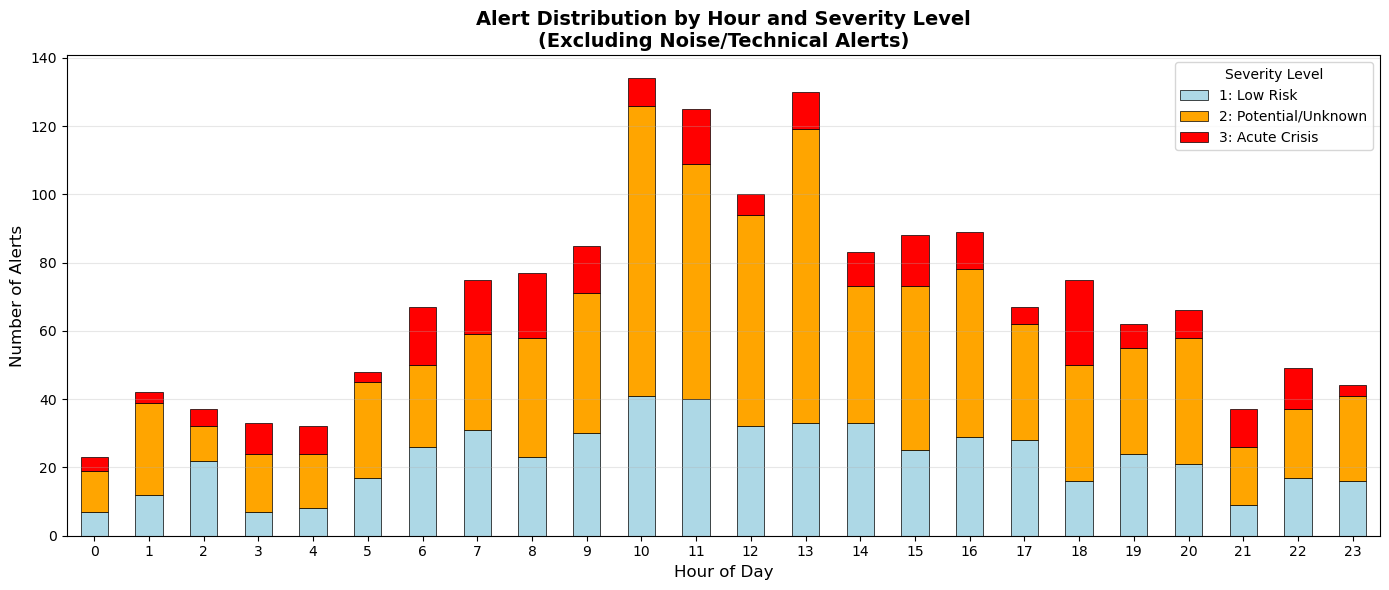

In [152]:
severity_colors = {
    '1: Low Risk': 'lightblue',
    '2: Potential/Unknown': 'orange',
    '3: Acute Crisis': 'red'
}

for severity in severity_colors.keys():
    if severity not in hourly_pivot.columns:
        hourly_pivot[severity] = 0

column_order = ['1: Low Risk', '2: Potential/Unknown', '3: Acute Crisis']
hourly_pivot = hourly_pivot[[col for col in column_order if col in hourly_pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 6))

hourly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[severity_colors.get(col, 'gray') for col in hourly_pivot.columns],
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Number of Alerts', fontsize=12)
ax.set_title('Alert Distribution by Hour and Severity Level\n(Excluding Noise/Technical Alerts)', fontsize=14, fontweight='bold')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), rotation=0)
ax.legend(title='Severity Level')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [153]:
hourly_pivot.astype(int)

severity_label,1: Low Risk,2: Potential/Unknown,3: Acute Crisis
hour,,,
0,7,12,4
1,12,27,3
2,22,10,5
3,7,17,9
4,8,16,8
5,17,28,3
6,26,24,17
7,31,28,16
8,23,35,19


## 8.3 Peak hours analysis

Identify peak alert hours and patterns.

In [154]:
hourly_totals = hourly_pivot.sum(axis=1).sort_values(ascending=False)

print("="*60)
print("TOP 5 PEAK ALERT HOURS")
print("="*60)
for hour, count in hourly_totals.head(5).items():
    print(f"Hour {hour:02d}:00 - {count:.0f} alerts")
    for severity in hourly_pivot.columns:
        severity_count = hourly_pivot.loc[hour, severity]
        if severity_count > 0:
            print(f"  - {severity}: {severity_count:.0f}")

print("\n" + "="*60)
print("TOP 5 QUIETEST HOURS")
print("="*60)
for hour, count in hourly_totals.tail(5).items():
    print(f"Hour {hour:02d}:00 - {count:.0f} alerts")

print("\n" + "="*60)
print("ALERT DISTRIBUTION BY TIME PERIOD")
print("="*60)

time_periods = {
    'Night (00:00-05:59)': range(0, 6),
    'Morning (06:00-11:59)': range(6, 12),
    'Afternoon (12:00-17:59)': range(12, 18),
    'Evening (18:00-23:59)': range(18, 24)
}

for period_name, hours in time_periods.items():
    period_alerts = hourly_totals[list(hours)].sum()
    period_percentage = (period_alerts / hourly_totals.sum()) * 100
    print(f"{period_name}: {period_alerts:.0f} alerts ({period_percentage:.1f}%)")

TOP 5 PEAK ALERT HOURS
Hour 10:00 - 134 alerts
  - 1: Low Risk: 41
  - 2: Potential/Unknown: 85
  - 3: Acute Crisis: 8
Hour 13:00 - 130 alerts
  - 1: Low Risk: 33
  - 2: Potential/Unknown: 86
  - 3: Acute Crisis: 11
Hour 11:00 - 125 alerts
  - 1: Low Risk: 40
  - 2: Potential/Unknown: 69
  - 3: Acute Crisis: 16
Hour 12:00 - 100 alerts
  - 1: Low Risk: 32
  - 2: Potential/Unknown: 62
  - 3: Acute Crisis: 6
Hour 16:00 - 89 alerts
  - 1: Low Risk: 29
  - 2: Potential/Unknown: 49
  - 3: Acute Crisis: 11

TOP 5 QUIETEST HOURS
Hour 21:00 - 37 alerts
Hour 02:00 - 37 alerts
Hour 03:00 - 33 alerts
Hour 04:00 - 32 alerts
Hour 00:00 - 23 alerts

ALERT DISTRIBUTION BY TIME PERIOD
Night (00:00-05:59): 215 alerts (12.9%)
Morning (06:00-11:59): 563 alerts (33.8%)
Afternoon (12:00-17:59): 557 alerts (33.4%)
Evening (18:00-23:59): 333 alerts (20.0%)


# 9. Vital Sign Profiles

Analyze vital sign patterns in the 2-hour window before alerts. For each severity level, calculate average Heart Rate and Pulse Pressure (SBP - DBP) leading up to the alert.

## 9.1 Extract measurements in 2-hour windows before alerts

For each alert, find all Heart Rate and Blood Pressure measurements in the 2 hours prior.

In [155]:
alerts_sorted = alerts_df[alerts_df['severity'] > 0].sort_values('alert_date')

con = duckdb.connect()
con.execute("INSTALL sqlite;")
con.execute("LOAD sqlite;")
con.execute("CALL sqlite_attach('../db/hrp_data.db');")

In [156]:
query = """
    SELECT 
        a.alert_id,
        a.senior_id,
        a.alert_date,
        a.severity_label,
        AVG(CASE WHEN m.type = 'Heartrate' THEN m.value END) AS avg_heart_rate,
        AVG(CASE WHEN m.type = 'BloodPressure' THEN (m.sbp - m.dbp) END) AS avg_pulse_pressure,
        COUNT(m.id) AS measurement_count
    FROM alerts_sorted a
    INNER JOIN measurements m 
        ON a.senior_id = m.senior_id
        -- The 2-hour lookback window logic:
        AND CAST(m.date AS TIMESTAMP) > (CAST(a.alert_date AS TIMESTAMP) - INTERVAL 2 HOUR)
        AND CAST(m.date AS TIMESTAMP) <= CAST(a.alert_date AS TIMESTAMP)
    GROUP BY 
        a.alert_id, a.senior_id, a.alert_date, a.severity_label
"""

vitals_stats = con.execute(query).df()

con.close()

print(f"{len(vitals_stats):,} alerts.")

display(vitals_stats.head())

1,430 alerts.


,alert_id,senior_id,alert_date,severity_label,avg_heart_rate,avg_pulse_pressure,measurement_count
0,1854,41497,2025-11-04 08:52:48,2: Potential/Unknown,54.916667,56.500000,51
1,3492,49651,2025-11-06 20:25:21,3: Acute Crisis,95.500000,53.000000,11
2,1587,38584,2025-11-11 23:20:53,1: Low Risk,70.250000,28.083333,47
3,1915,41962,2025-11-10 10:28:41,1: Low Risk,NaN,NaN,1
4,1095,34488,2025-11-21 06:52:47,3: Acute Crisis,71.555556,50.333333,37


## 9.2 Summary statistics by severity level

In [157]:
analysis_df = vitals_stats.copy()

analysis_df_pp = analysis_df[
    (analysis_df['avg_pulse_pressure'] > (SBP_min - DBP_min - 20)) & 
    (analysis_df['avg_pulse_pressure'] < (SBP_max - DBP_max + 20))
].dropna(subset=['avg_pulse_pressure'])

analysis_df_hr = analysis_df.dropna(subset=['avg_heart_rate'])

In [158]:
print("HEART RATE STATISTICS (2H WINDOW) BY SEVERITY LEVEL")
hr_stats = analysis_df_hr.groupby('severity_label')['avg_heart_rate'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)
hr_stats.round(2)

HEART RATE STATISTICS (2H WINDOW) BY SEVERITY LEVEL


,count,mean,std,min,max
severity_label,,,,,
1: Low Risk,441,77.69,11.60,49.42,125.00
2: Potential/Unknown,695,76.98,12.01,45.50,125.00
3: Acute Crisis,189,80.73,14.00,52.29,138.67


In [159]:
print("PULSE PRESSURE STATISTICS (2H WINDOW) BY SEVERITY LEVEL")
pp_stats = analysis_df_pp.groupby('severity_label')['avg_pulse_pressure'].agg(
    ['count', 'mean', 'std', 'min', 'max']
)
pp_stats.round(2)

PULSE PRESSURE STATISTICS (2H WINDOW) BY SEVERITY LEVEL


,count,mean,std,min,max
severity_label,,,,,
1: Low Risk,441,52.29,11.06,22.50,106.92
2: Potential/Unknown,694,51.21,10.07,23.42,92.91
3: Acute Crisis,189,52.24,11.31,18.38,92.25


In [160]:
# 5. Data Completeness Check
print("WINDOW DATA COMPLETENESS")
coverage = analysis_df.groupby('severity_label').agg({
    'measurement_count': ['mean', 'median', 'max']
})
print("Average measurements found per 2h window:")
coverage.round(1)

WINDOW DATA COMPLETENESS
Average measurements found per 2h window:


measurement_count            
                                  mean median  max
severity_label                                    
1: Low Risk                       40.8   48.0  232
2: Potential/Unknown              41.7   48.0  239
3: Acute Crisis                   32.6   42.0   69

In [161]:
print("Note: A sudden drop in measurement frequency is actually a feature! In remote monitoring, " \
    "\"Silence\" from the sensor is a high-risk indicator," \
    " therefore lower number of measurements during acute crisis is to be expedcted.")

Note: A sudden drop in measurement frequency is actually a feature! In remote monitoring, "Silence" from the sensor is a high-risk indicator, therefore lower number of measurements during acute crisis is to be expedcted.


## 9.3 Boxplot visualization

Visualize the distribution of Heart Rate and Pulse Pressure across severity levels.

C:\Users\eldar\AppData\Local\Temp\ipykernel_49060\964412563.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(hr_data, labels=hr_labels, patch_artist=True,
C:\Users\eldar\AppData\Local\Temp\ipykernel_49060\964412563.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(pp_data, labels=pp_labels, patch_artist=True,


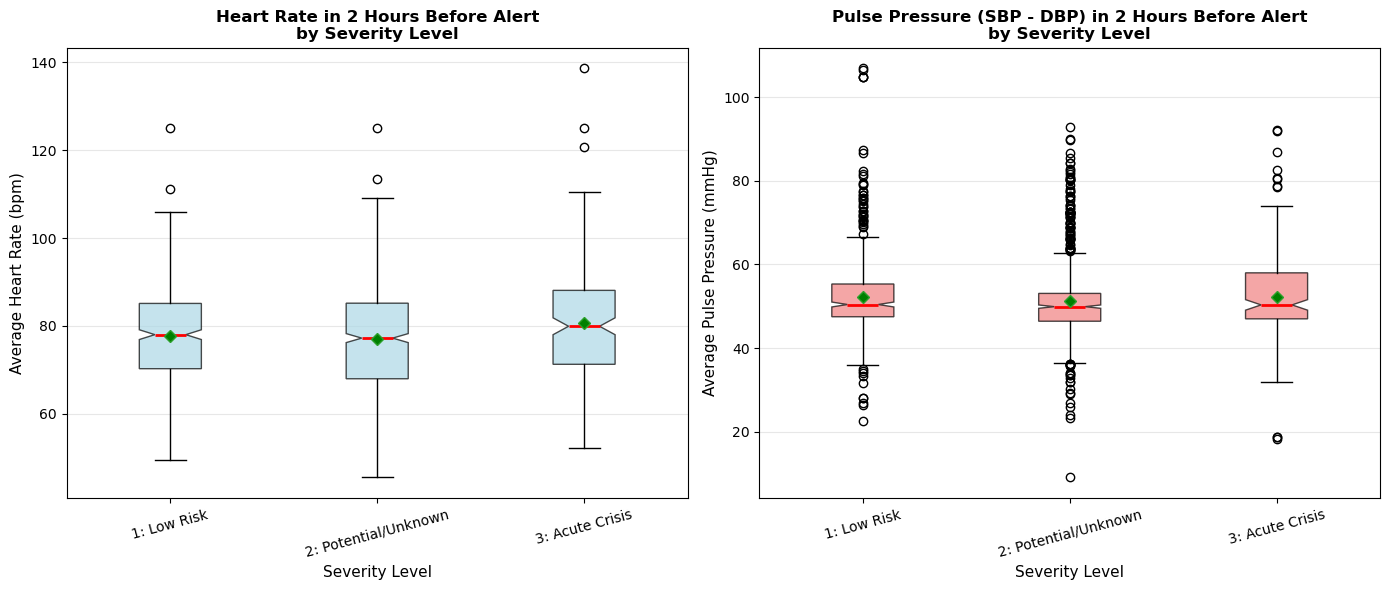


Note: Red line = median, Green diamond = mean


In [162]:
vitals_with_hr = vitals_stats.dropna(subset=['avg_heart_rate'])
vitals_with_pp = vitals_stats.dropna(subset=['avg_pulse_pressure'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

severity_order = ['1: Low Risk', '2: Potential/Unknown', '3: Acute Crisis']

hr_data = [vitals_with_hr[vitals_with_hr['severity_label'] == sev]['avg_heart_rate'].values 
           for sev in severity_order if sev in vitals_with_hr['severity_label'].values]
hr_labels = [sev for sev in severity_order if sev in vitals_with_hr['severity_label'].values]

pp_data = [vitals_with_pp[vitals_with_pp['severity_label'] == sev]['avg_pulse_pressure'].values 
           for sev in severity_order if sev in vitals_with_pp['severity_label'].values]
pp_labels = [sev for sev in severity_order if sev in vitals_with_pp['severity_label'].values]

bp1 = axes[0].boxplot(hr_data, labels=hr_labels, patch_artist=True, 
                       notch=True, showmeans=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2),
                       meanprops=dict(marker='D', markerfacecolor='green', markersize=6))
axes[0].set_xlabel('Severity Level', fontsize=11)
axes[0].set_ylabel('Average Heart Rate (bpm)', fontsize=11)
axes[0].set_title('Heart Rate in 2 Hours Before Alert\nby Severity Level', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

bp2 = axes[1].boxplot(pp_data, labels=pp_labels, patch_artist=True,
                       notch=True, showmeans=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2),
                       meanprops=dict(marker='D', markerfacecolor='green', markersize=6))
axes[1].set_xlabel('Severity Level', fontsize=11)
axes[1].set_ylabel('Average Pulse Pressure (mmHg)', fontsize=11)
axes[1].set_title('Pulse Pressure (SBP - DBP) in 2 Hours Before Alert\nby Severity Level', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Red line = median, Green diamond = mean")

# 10. Chronic Linkage

Analyze the relationship between chronic diseases and alert severity levels. Identify which diseases are most strongly associated with Level 3 (Acute Crisis) alerts.

## 10.1 Disease association with Level 3 alerts

For each disease, calculate the percentage of affected seniors who experience Level 3 (Acute Crisis) alerts.

In [163]:
seniors_with_level3 = set(alerts_df[alerts_df['severity_label'] == '3: Acute Crisis']['senior_id'].unique())
print(f"Total seniors with Level 3 (Acute Crisis) alerts: {len(seniors_with_level3)}")

disease_stats = []

for disease_id in diseases_lookup['id'].unique():
    disease_name = diseases_lookup[diseases_lookup['id'] == disease_id]['disease_name'].values[0]
    
    seniors_with_disease = set(diseases_df[diseases_df['disease_id'] == disease_id]['senior_id'].unique())
    num_with_disease = len(seniors_with_disease)
    
    seniors_with_disease_and_l3 = seniors_with_disease & seniors_with_level3
    num_with_disease_and_l3 = len(seniors_with_disease_and_l3)
    
    if num_with_disease > 0:
        pct_with_l3 = (num_with_disease_and_l3 / num_with_disease) * 100
    else:
        pct_with_l3 = 0
    
    disease_stats.append({
        'disease_id': disease_id,
        'disease_name': disease_name,
        'seniors_with_disease': num_with_disease,
        'seniors_with_l3': num_with_disease_and_l3,
        'pct_with_l3': pct_with_l3
    })

disease_correlation_df = pd.DataFrame(disease_stats)
disease_correlation_df = disease_correlation_df.sort_values('pct_with_l3', ascending=False)

print("\nTop 10 diseases by Level 3 alert association:")
disease_correlation_df.head(10)

Total seniors with Level 3 (Acute Crisis) alerts: 178

Top 10 diseases by Level 3 alert association:


,disease_id,disease_name,seniors_with_disease,seniors_with_l3,pct_with_l3
138,139,choroby metaboliczne,5,1,20.000000
113,114,Zaburzenia gospodarki lipidowej,25,3,12.000000
148,149,Choroba uchyłkowa jelita (ogólnie),19,2,10.526316
60,61,Przepuklina pachwinowa,10,1,10.000000
77,78,Przepuklina rozworu przełykowego,14,1,7.142857
79,80,Utrwalone migotanie przedsionków,14,1,7.142857
117,118,Problemy ze wzrokiem (ogólnie),33,2,6.060606
97,98,Wzrok,53,3,5.660377
104,105,Otępienie,36,2,5.555556
100,101,Rozedma płuc,80,4,5.000000


In [164]:
total_seniors_in_study = seniors_df['id'].nunique()
total_with_l3 = len(seniors_with_level3)

print("Disease–Level 3 alert association (top 15 by patient count, Fisher's exact / chi-square):")
print("=" * 85)
print(f"{'Disease':<40} {'N':>5}  {'L3%':>6}  {'p-value':>10}  {'Sig':>4}")
print("-" * 85)

sig_diseases = disease_correlation_df[disease_correlation_df['seniors_with_disease'] >= 10].copy()

for _, row in sig_diseases.head(15).iterrows():
    a = row['seniors_with_l3']                          # has disease AND L3
    b = row['seniors_with_disease'] - a                 # has disease, no L3
    c = total_with_l3 - a                               # no disease, has L3
    d = total_seniors_in_study - a - b - c              # neither

    contingency = [[a, b], [c, d]]
    if row['seniors_with_disease'] < 30:
        _, p = fisher_exact(contingency, alternative='greater')
        test = 'Fisher'
    else:
        _, p, _, _ = chi2_contingency(contingency)
        test = 'Chi2'

    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{row['disease_name'][:39]:<40} {row['seniors_with_disease']:>5}  "
          f"{row['pct_with_l3']:>5.1f}%  {p:>10.4f}  {sig:>4}  ({test})")

print("\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")

Disease–Level 3 alert association (top 15 by patient count, Fisher's exact / chi-square):
Disease                                      N     L3%     p-value   Sig
-------------------------------------------------------------------------------------
Zaburzenia gospodarki lipidowej             25   12.0%      0.0032    **  (Fisher)
Choroba uchyłkowa jelita (ogólnie)          19   10.5%      0.0212     *  (Fisher)
Przepuklina pachwinowa                      10   10.0%      0.1131    ns  (Fisher)
Przepuklina rozworu przełykowego            14    7.1%      0.1546    ns  (Fisher)
Utrwalone migotanie przedsionków            14    7.1%      0.1546    ns  (Fisher)
Problemy ze wzrokiem (ogólnie)              33    6.1%      0.0756    ns  (Chi2)
Wzrok                                       53    5.7%      0.0179     *  (Chi2)
Otępienie                                   36    5.6%      0.0997    ns  (Chi2)
Rozedma płuc                                80    5.0%      0.0085    **  (Chi2)
Tętniak (bez

In [165]:
avg_l3_pct = disease_correlation_df['pct_with_l3'].mean()
print(f"Average percentage of disease patients with Level 3 alerts: {avg_l3_pct:.1f}%")

Average percentage of disease patients with Level 3 alerts: 1.4%


## 10.2 Categorize diseases into clinical groups

Group diseases by clinical category using Polish medical keywords.

In [166]:
disease_categories = {
    'cardiovascular': [
        'serc', 'nadciśnien', 'ciśnien', 'arytmi', 'migotani',
        'trzepotani', 'niewydolność serca', 'zawał',
        'wieńc', 'miażdżyc', 'aort', 'tętniak',
        'dusznica', 'zakrzep', 'zator', 'płucn',
        'kołatanie', 'hipotensj'
    ],

    'metabolic_endocrine': [
        'cukrzyc', 'insulin', 'lipid', 'cholesterol',
        'hiperlipid', 'otyło', 'nadwag',
        'tarczyc', 'hashimoto', 'metabolic',
        'endokryn', 'hipoglik', 'stan przedcukrzyc'
    ],

    'neurological': [
        'udar', 'neurolog', 'padaczk',
        'parkinson', 'stwardnieni',
        'neuropat', 'polineurop',
        'rwa', 'zawrot', 'omdleni'
    ],

    'psychiatric_cognitive': [
        'depresj', 'nerwic', 'lękow',
        'schizofren', 'psychicz',
        'demencj', 'otępieni',
        'alzheimer', 'zanik pamięci',
        'bezsenność'
    ],

    'musculoskeletal': [
        'staw', 'kostn', 'reumaty',
        'zwyrodnieni', 'kręgosłup',
        'dyskopati', 'skolioz',
        'osteoporoz', 'osteopeni',
        'endoprotez', 'lasce', 'chodzeni'
    ],

    'respiratory': [
        'astm', 'pochp', 'rozedm',
        'oddech', 'bezdech',
        'duszno', 'płuc'
    ],

    'gastro_renal_urologic': [
        'żołądk', 'jelit', 'refluks',
        'wrzod', 'uchyłk', 'przepuklin',
        'wątroba', 'trzustk', 'żółci',
        'nerk', 'kamica', 'mocz',
        'prostat'
    ],

    'oncological': [
        'nowotwór', 'rak',
        'onkolog', 'guzy',
        'mastektomia'
    ],

    'sensory': [
        'wzrok', 'widzeni', 'zaćm',
        'jaskr', 'plamki',
        'słuch', 'niedosłuch',
        'głuchot', 'szumy uszne'
    ],

    'other_functional_risk': [
        'niepełnosprawność', 'porusz',
        'chodzeni', 'laska',
        'nikotyn', 'palenie',
        'autoimmun', 'łuszczyc',
        'borelioz', 'anemi',
        'implant', 'stent',
        'rozrusznik', 'bajpas'
    ]
}

In [167]:
def categorize_disease(disease_name):
    disease_lower = disease_name.lower()
    
    for category, keywords in disease_categories.items():
        for keyword in keywords:
            if keyword in disease_lower:
                return category
    
    return 'unclassified'

disease_correlation_df['category'] = disease_correlation_df['disease_name'].apply(categorize_disease)

category_counts = disease_correlation_df['category'].value_counts()
print("Disease Distribution by Category:")
print("="*60)
for category, count in category_counts.items():
    pct = (count / len(disease_correlation_df)) * 100
    print(f"{category:25s}: {count:3d} diseases ({pct:5.1f}%)")

Disease Distribution by Category:
unclassified             :  28 diseases ( 17.4%)
cardiovascular           :  27 diseases ( 16.8%)
metabolic_endocrine      :  21 diseases ( 13.0%)
gastro_renal_urologic    :  18 diseases ( 11.2%)
musculoskeletal          :  18 diseases ( 11.2%)
psychiatric_cognitive    :  11 diseases (  6.8%)
sensory                  :  10 diseases (  6.2%)
neurological             :   9 diseases (  5.6%)
respiratory              :   7 diseases (  4.3%)
other_functional_risk    :   7 diseases (  4.3%)
oncological              :   5 diseases (  3.1%)


## 10.3 Top diseases by category with Level 3 alert correlation

In [168]:
print("="*80)
print("TOP DISEASES PER CATEGORY WITH HIGHEST LEVEL 3 ALERT CORRELATION")
print("="*80)

for category in disease_categories.keys():
    print(f"\nCategory: {category}")
    top_diseases = disease_correlation_df[
        disease_correlation_df['category'] == category
    ].sort_values('pct_with_l3', ascending=False).head(5)
    
    for _, row in top_diseases.iterrows():
        print(f"  - {row['disease_name']} | Patients: {row['seniors_with_disease']} | "
              f"Level 3 Alerts: {row['seniors_with_l3']} ({row['pct_with_l3']:.1f}%)")

TOP DISEASES PER CATEGORY WITH HIGHEST LEVEL 3 ALERT CORRELATION

Category: cardiovascular
  - Utrwalone migotanie przedsionków | Patients: 14 | Level 3 Alerts: 1 (7.1%)
  - Tętniak (bez umiejscowienia) | Patients: 60 | Level 3 Alerts: 3 (5.0%)
  - Przewlekła niewydolność serca | Patients: 27 | Level 3 Alerts: 1 (3.7%)
  - Wada wrodzone serca | Patients: 102 | Level 3 Alerts: 3 (2.9%)
  - Stent (Obecność implantów i przeszczepów związanych z angioplastyką wieńcową) | Patients: 120 | Level 3 Alerts: 3 (2.5%)

Category: metabolic_endocrine
  - choroby metaboliczne | Patients: 5 | Level 3 Alerts: 1 (20.0%)
  - Zaburzenia gospodarki lipidowej | Patients: 25 | Level 3 Alerts: 3 (12.0%)
  - Tarczyca | Patients: 235 | Level 3 Alerts: 4 (1.7%)
  - Cukrzyca typu 1 | Patients: 294 | Level 3 Alerts: 5 (1.7%)
  - nadwaga | Patients: 932 | Level 3 Alerts: 14 (1.5%)

Category: neurological
  - Neuropatia | Patients: 27 | Level 3 Alerts: 1 (3.7%)
  - Stwardnienie rozsiane | Patients: 36 | Level 3 Ale

## 10.4 Visualization: Level 3 alert rates by disease category

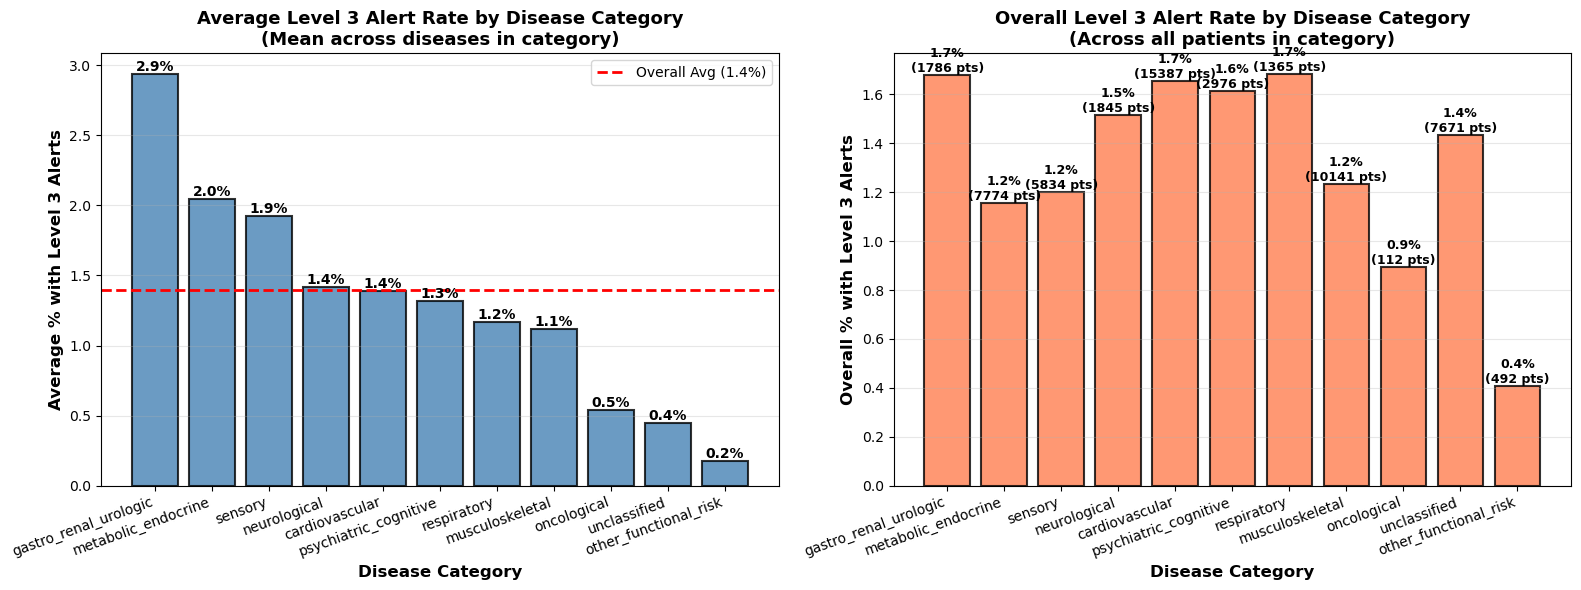

,pct_with_l3,seniors_with_disease,seniors_with_l3,overall_pct
category,,,,
gastro_renal_urologic,2.9,1786,30,1.7
metabolic_endocrine,2.0,7774,90,1.2
sensory,1.9,5834,70,1.2
neurological,1.4,1845,28,1.5
cardiovascular,1.4,15387,255,1.7
psychiatric_cognitive,1.3,2976,48,1.6
respiratory,1.2,1365,23,1.7
musculoskeletal,1.1,10141,125,1.2
oncological,0.5,112,1,0.9


In [169]:
category_avg_l3 = disease_correlation_df.groupby('category').agg({
    'pct_with_l3': 'mean',
    'seniors_with_disease': 'sum',
    'seniors_with_l3': 'sum'
}).sort_values('pct_with_l3', ascending=False)

category_avg_l3['overall_pct'] = (category_avg_l3['seniors_with_l3'] / category_avg_l3['seniors_with_disease'] * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

categories = category_avg_l3.index
avg_pcts = category_avg_l3['pct_with_l3'].values

bars1 = axes[0].bar(range(len(categories)), avg_pcts, color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Disease Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average % with Level 3 Alerts', fontsize=12, fontweight='bold')
axes[0].set_title('Average Level 3 Alert Rate by Disease Category\n(Mean across diseases in category)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(categories)))
axes[0].set_xticklabels(categories, rotation=20, ha='right')
axes[0].axhline(y=avg_l3_pct, color='red', linestyle='--', linewidth=2, label=f'Overall Avg ({avg_l3_pct:.1f}%)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

for i, (bar, pct) in enumerate(zip(bars1, avg_pcts)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

overall_pcts = category_avg_l3['overall_pct'].values
patients_per_category = category_avg_l3['seniors_with_disease'].values

bars2 = axes[1].bar(range(len(categories)), overall_pcts, color='coral', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel('Disease Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Overall % with Level 3 Alerts', fontsize=12, fontweight='bold')
axes[1].set_title('Overall Level 3 Alert Rate by Disease Category\n(Across all patients in category)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(categories)))
axes[1].set_xticklabels(categories, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, pct, total) in enumerate(zip(bars2, overall_pcts, patients_per_category)):  # updated here too
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%\n({int(total)} pts)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

category_avg_l3.round(1)

In [202]:
conn.close()
con.close()
print("Database connections closed.")

Database connections closed.
